# Сессионное задание. Линейная алгебра

Давайте немного пофантазируем и даже помечтаем: вы успешно окончили магистратуру, нашли первую работу на позиции начинающего дата-сайентиста, а затем начался стремительный карьерный рост и рост вашего благосостояния. В итоге сложился первый капитал. Во что его эффективно вложить?

Чтобы принимать взвешенные решения, нужно научиться строить модели и анализировать данные. Вы построите модель, которая сможет предсказывать цену квартиры по её характеристикам.

Рабочая таблица с данными:

|Комнаты|Площадь|Этаж |Центр|Спальный 1|Спальный 2|Цена|
|:-----:|:-----:|:---:|:---:|:----:|:---:|:---:|
|3   |	51|	3|	0|	1|	0|	2200|
|1   |	30|	1|	0|  1|	0|	1600|
|2   |	45|	2|	0|	1|	0|	1900|
|3   |	55|	1|	0|	1|	0|	2000|
|1   |	45|	3|	1|	0|	0|	4500|

## Задание 1. Ассоциативность умножения матриц

Прежде чем строить модель для предсказания цен, посмотрите, как устроены данные. Мы уже представили их в виде таблицы, но для дальнейшей работы их нужно перевести в **матричную форму**.
* Пусть $Х$ — это **матрица признаков**. Её размерность: 3 строки x 3 столбца. Возьмем 3 первые квартиры и 3 признака: «Комнаты». «Площадь» и «Этаж».
* Пусть $Y$ — это **вектор-столбец** цен для этих трех квартир. Его размерность: 3 строки x 1 столбец.

В регрессии вы будете часто встречаться с выражением вида:

$(X^T X)^{-1} X^T Y$

Оно включает несколько последовательных умножений матриц и векторов. Но порядок группировки этих операций может влиять на **вычислительную эффективность**.

### Задача:

1. Вычислите результат умножения $X^T (X Y)$.
2. Выполните вычисления двумя способами и сравните количество скалярных операций (умножений и сложений):
    - **Способ 1** (скобки справа): сначала вычислите $u = X Y$. затем вычислите $X^Tu$.  
    ($u$ - для промежуточных вычислений)
    - **Способ 2** (скобки слева): сначала вычислите $M = X^T X$. затем вычислите $MY$.  
    ($M$ - для промежуточных вычислений)
3. Сравните количество скалярных операций в каждом способе.
4. Сделайте вывод: почему в задачах анализа данных важно выбирать порядок вычислений. если матрицы могут быть очень большими?

### Решение

# Решение задачи по линейной алгебре
# Все формулы в формате LaTex для Jupyter Notebook

## 1. Формирование матрицы признаков X и вектора Y

Матрица признаков X (3×3):
$$
X = \begin{pmatrix}
3 & 51 & 3 \\
1 & 30 & 1 \\
2 & 45 & 2
\end{pmatrix}
$$

Вектор-столбец Y (3×1):
$$
Y = \begin{pmatrix}
2200 \\
1600 \\
1900
\end{pmatrix}
$$

## 2. Вычисление $X^T (X Y)$ двумя способами

### Способ 1: сначала вычисляем $u = X Y$, затем $X^T u$

#### Шаг 1: $u = X Y$
$$
u = \begin{pmatrix}
3 & 51 & 3 \\
1 & 30 & 1 \\
2 & 45 & 2
\end{pmatrix}
\begin{pmatrix}
2200 \\
1600 \\
1900
\end{pmatrix}
$$

Вычисляем поэлементно:
- Первая строка: $3 \cdot 2200 + 51 \cdot 1600 + 3 \cdot 1900 = 6600 + 81600 + 5700 = 93900$
- Вторая строка: $1 \cdot 2200 + 30 \cdot 1600 + 1 \cdot 1900 = 2200 + 48000 + 1900 = 52100$
- Третья строка: $2 \cdot 2200 + 45 \cdot 1600 + 2 \cdot 1900 = 4400 + 72000 + 3800 = 80200$

Таким образом:
$$
u = \begin{pmatrix}
93900 \\
52100 \\
80200
\end{pmatrix}
$$

#### Шаг 2: вычисляем $X^T u$

Транспонированная матрица:
$$
X^T = \begin{pmatrix}
3 & 1 & 2 \\
51 & 30 & 45 \\
3 & 1 & 2
\end{pmatrix}
$$

Умножаем:
$$
X^T u = \begin{pmatrix}
3 & 1 & 2 \\
51 & 30 & 45 \\
3 & 1 & 2
\end{pmatrix}
\begin{pmatrix}
93900 \\
52100 \\
80200
\end{pmatrix}
$$

Вычисляем:
- Первый элемент: $3 \cdot 93900 + 1 \cdot 52100 + 2 \cdot 80200 = 281700 + 52100 + 160400 = 494200$
- Второй элемент: $51 \cdot 93900 + 30 \cdot 52100 + 45 \cdot 80200 = 4788900 + 1563000 + 3609000 = 9960900$
- Третий элемент: $3 \cdot 93900 + 1 \cdot 52100 + 2 \cdot 80200 = 281700 + 52100 + 160400 = 494200$

Итог способа 1:
$$
X^T (X Y) = \begin{pmatrix}
494200 \\
9960900 \\
494200
\end{pmatrix}
$$

### Способ 2: сначала вычисляем $M = X^T X$, затем $M Y$

#### Шаг 1: $M = X^T X$
$$
M = X^T X = \begin{pmatrix}
3 & 1 & 2 \\
51 & 30 & 45 \\
3 & 1 & 2
\end{pmatrix}
\begin{pmatrix}
3 & 51 & 3 \\
1 & 30 & 1 \\
2 & 45 & 2
\end{pmatrix}
$$

Вычисляем элементы:
- $M_{11} = 3\cdot3 + 1\cdot1 + 2\cdot2 = 9 + 1 + 4 = 14$
- $M_{12} = 3\cdot51 + 1\cdot30 + 2\cdot45 = 153 + 30 + 90 = 273$
- $M_{13} = 3\cdot3 + 1\cdot1 + 2\cdot2 = 9 + 1 + 4 = 14$
- $M_{21} = 51\cdot3 + 30\cdot1 + 45\cdot2 = 153 + 30 + 90 = 273$
- $M_{22} = 51\cdot51 + 30\cdot30 + 45\cdot45 = 2601 + 900 + 2025 = 5526$
- $M_{23} = 51\cdot3 + 30\cdot1 + 45\cdot2 = 153 + 30 + 90 = 273$
- $M_{31} = 3\cdot3 + 1\cdot1 + 2\cdot2 = 9 + 1 + 4 = 14$
- $M_{32} = 3\cdot51 + 1\cdot30 + 2\cdot45 = 153 + 30 + 90 = 273$
- $M_{33} = 3\cdot3 + 1\cdot1 + 2\cdot2 = 9 + 1 + 4 = 14$

Таким образом:
$$
M = \begin{pmatrix}
14 & 273 & 14 \\
273 & 5526 & 273 \\
14 & 273 & 14
\end{pmatrix}
$$

#### Шаг 2: вычисляем $M Y$
$$
M Y = \begin{pmatrix}
14 & 273 & 14 \\
273 & 5526 & 273 \\
14 & 273 & 14
\end{pmatrix}
\begin{pmatrix}
2200 \\
1600 \\
1900
\end{pmatrix}
$$

Вычисляем:
- Первый элемент: $14 \cdot 2200 + 273 \cdot 1600 + 14 \cdot 1900 = 30800 + 436800 + 26600 = 494200$
- Второй элемент: $273 \cdot 2200 + 5526 \cdot 1600 + 273 \cdot 1900 = 600600 + 8841600 + 518700 = 9960900$
- Третий элемент: $14 \cdot 2200 + 273 \cdot 1600 + 14 \cdot 1900 = 30800 + 436800 + 26600 = 494200$

Итог способа 2:
$$
(X^T X) Y = \begin{pmatrix}
494200 \\
9960900 \\
494200
\end{pmatrix}
$$

## 3. Сравнение количества скалярных операций

Пусть $X$ имеет размер $m \times n$ (у нас $m=3$, $n=3$), $Y$ — $m \times 1$.

### Способ 1: $(X Y)$ затем $X^T (X Y)$
1. Вычисление $X Y$:
   - Умножений: $m \cdot n = 3 \cdot 3 = 9$
   - Сложений: $m \cdot (n-1) = 3 \cdot 2 = 6$
   - Итого: $9 + 6 = 15$ операций

2. Вычисление $X^T u$:
   - Умножений: $n \cdot m = 3 \cdot 3 = 9$
   - Сложений: $n \cdot (m-1) = 3 \cdot 2 = 6$
   - Итого: $9 + 6 = 15$ операций

**Всего для способа 1:** $15 + 15 = 30$ скалярных операций

### Способ 2: $(X^T X)$ затем $(X^T X) Y$
1. Вычисление $X^T X$:
   - Умножений: $n \cdot m \cdot n = 3 \cdot 3 \cdot 3 = 27$
   - Сложений: $n \cdot n \cdot (m-1) = 3 \cdot 3 \cdot 2 = 18$
   - Итого: $27 + 18 = 45$ операций

2. Вычисление $M Y$:
   - Умножений: $n \cdot n = 9$
   - Сложений: $n \cdot (n-1) = 3 \cdot 2 = 6$
   - Итого: $9 + 6 = 15$ операций

**Всего для способа 2:** $45 + 15 = 60$ скалярных операций

## 4. Вывод

Для данных размеров ($m=3$, $n=3$) способ 1 требует **30 операций**, способ 2 — **60 операций**.

В задачах анализа данных с большими матрицами ($m$ — десятки/сотни тысяч, $n$ — сотни) выбор порядка вычислений критически важен:
1. **Эффективность вычислений**: разница в количестве операций может составлять порядки величины
2. **Использование памяти**: промежуточные матрицы могут требовать значительных ресурсов
3. **Время выполнения**: лишние операции на больших данных существенно замедляют расчеты

В общем случае при $m \gg n$:
- Способ 1 выгоднее для однократного вычисления $X^T(X Y)$
- Способ 2 (через $X^T X$) часто используется в регрессии, так как матрица $X^T X$ размером $n \times n$ мала и может использоваться многократно

**Итоговый ответ:**
$$
X^T (X Y) = \begin{pmatrix} 494200 \\ 9960900 \\ 494200 \end{pmatrix}
$$
Количество операций:
- Способ 1: 30
- Способ 2: 60

Перемножим матрицы $X$ и $Y$ двумя способами
$$
X = \begin{pmatrix}
3 & 51 & 3 \\
1 & 30 & 1 \\
2 & 45 & 2
\end{pmatrix}
;
Y = \begin{pmatrix}
2200 \\
1600 \\
1900
\end{pmatrix}
$$


![Способ 1](linal_session_task_1_1.jpg)

![Способ 2](linal_session_task_1_2.jpg)

# Задание 2. Связь признаков с ценой


В реальной жизни дата-сайентист всегда спрашивает: «Какие факторы сильнее всего влияют на результат?» Для вас результат — это **цена квартиры**, а признаки — её характеристики (площадь, этаж, район и так далее).

* Для числовых признаков (как «Площадь», «Комнаты», «Этаж») корреляция Пирсона измеряет силу линейной зависимости с ценой.
* Для бинарных признаков (как «Центр», «Спальный 1», «Спальный 2») коэффициент корреляции Пирсона вычисляется точно по той же формуле, но в статистике такой случай имеет специальное название — точечно-бисериальная корреляция. Она показывает, насколько наличие характеристики (значение 1) связано с изменением среднего значения цены по сравнению с её отсутствием (значение 0).

**Важно**: Поскольку вычисления проводятся по одинаковой формуле, вы можете использовать одну и ту же функцию для расчета корреляции всех признаков с ценой.

Чтобы ответить на этот вопрос, примените корреляцию. Она покажет, насколько признак связан с ценой:
* сильная положительная корреляция → рост признака увеличивает цену;
* слабая или нулевая → признак почти не влияет;
* отрицательная → признак растёт, а цена падает.

## Задача:

1. Составьте матрицу признаков $X$ и вектор цен $Y$.
2. Для каждого признака вычислите коэффициент корреляции с ценой.
3. Определите признак с наибольшей и наименьшей связью.
4. Объясните, почему выделение таких признаков важно для предсказательной модели.
5. Для бинарных признаков дайте содержательную интерпретацию: что означает положительный или отрицательный знак корреляции?
* Дополнительное задание*
* * Для одного из бинарных признаков проверьте свой вывод: сравните среднюю цену для квартир, где признак равен 1, и для квартир, где признак равен 0.

## Решение:

Зададим векторы признаков Х и целевой вектор цены Y:

$
\vec{x}_1=\left(\begin{array}{l} 3 \\ 1 \\ 2 \\ 3 \\ 1 \end{array}\right) 
\text {, } 
\vec{x}_2=\left(\begin{array}{l} 51 \\ 30 \\ 45 \\ 55 \\ 45  \end{array}\right)
\text {, } 
\vec{x}_3=\left(\begin{array}{l} 3 \\ 1 \\ 2 \\ 1 \\ 3  \end{array}\right)
\text {, } 
\vec{x}_4=\left(\begin{array}{l} 0 \\ 0 \\ 0 \\ 0 \\ 1  \end{array}\right)
\text {, } 
\vec{x}_5=\left(\begin{array}{l} 1 \\ 1 \\ 1 \\ 1 \\ 0  \end{array}\right)
\text {, } 
\vec{x}_6=\left(\begin{array}{l} 0 \\ 0 \\ 0 \\ 0 \\ 0  \end{array}\right)
\text { и } 
\vec{y}=\left(\begin{array}{l} 2200 \\ 1600 \\ 1900 \\ 2000 \\ 4500  \end{array}\right)
$

Приведём векторы к единому масштабу. произведем центрированние и стандартизирование векторов. 
Для центрирования из каждого ветора вычтем вектор из средних значений. Так мы получим. что у всех векторов середина будет на нуле.

Теперь из каждого значения вектора вычтем средний вектор и найдём его длину. после этого разделим центрированный вектор на его длину. так мы получим стандартизированный вектор со значениями в диапазоне [-1. 1]. Так мы попробуем сравнить вектора значений не взирая на масштаб.

х_6 ожидаемо равен нулю.

Для стандартизации разделим центрированные вектора на их длину. так мы получим единый масштаб для всех векторов [-1. 1].

$\vec{x}_{cent} = \vec{x} - \vec{x}_{mean}$

$\vec{x}_{st} =  \frac{\vec{x}_{cent}}{ \| \vec{x}_{cent} \| }$


$\vec{x}_{1_{mean}} = (2. 2. 2. 2. 2)^T: (3 + 1 + 2 + 3 + 1) / 5 = 10 / 5 = 2$ 

$
\vec{x}_{1_{cent}} = 
\left(\begin{array}{l} 3 \\ 1 \\ 2 \\ 3 \\ 1 \end{array}\right)
\text { - } 
\left(\begin{array}{l} 2 \\ 2 \\ 2 \\ 2 \\ 2 \end{array}\right)
\text { = } 
\left(\begin{array}{l} \enspace 1 \\ -1 \\ \enspace 0 \\ \enspace 1 \\ -1 \end{array}\right)
$

$
\left\|{x}_{1_{cent}} \right\| = \sqrt{(1)^2 + (-1)^2 + (0)^2 + (1)^2 + (-1)^2} = \sqrt{4} = 2
$

$
\vec{x}_{1_{st}} = \frac{1}{2}
\left(\begin{array}{l} \enspace 1 \\ -1 \\ \enspace 0 \\ \enspace 1 \\ -1 \end{array}\right)
\text { = }
\left(\begin{array}{l} \enspace \frac{1}{2} \\ -\frac{1}{2} \\ \enspace 0 \\ \enspace \frac{1}{2} \\ -\frac{1}{2} \end{array}\right) 
$

$\vec{x}_{2_{mean}} = (51 + 30 + 45 + 55 + 45) / 5 = 226 / 5 = 45 \frac{1}{5}$

$
\vec{x}_{2_{cent}}=
\left(\begin{array}{l} 51 \\ 30 \\ 45 \\ 55 \\ 45  \end{array}\right)
\text { - }
\left(\begin{array}{l} 45 \frac{1}{5} \\ 45 \frac{1}{5} \\ 45 \frac{1}{5} \\ 45 \frac{1}{5} \\ 45 \frac{1}{5}  \end{array}\right)
\text { = } 
\left(\begin{array}{l} \enspace \frac{29}{5} \\ -\frac{76}{5} \\ -\frac{1}{5} \\ \enspace \frac{49}{5} \\ -\frac{1}{5} \end{array}\right)
\text { = } 
\frac{1}{5} \left(\begin{array}{l} \enspace 29 \\ -76 \\ -1 \\ \enspace 49 \\ -1 \end{array}\right)
$

$
\left\|{x}_{2_{cent}} \right\| = \sqrt{(\frac{29}{5})^2 + (-\frac{76}{5})^2 + (-\frac{1}{5})^2 + (\frac{49}{5})^2 + (-\frac{1}{5})^2} = \frac{1}{5}\sqrt{841+5776+1+2401+1} = \frac{1}{5}\sqrt{9020} = $

$= \frac{1}{5}\sqrt{2^2 \cdot 5 \cdot 451} = \frac{2}{5}\sqrt{2255} \approx 18.99474$. или

$= \frac{1}{5}\sqrt{9025 - 5} = \frac{1}{5} \cdot 95 \sqrt{1 - \frac{5}{95^2}} 
 = 19 \sqrt{1 - \frac{5}{95^2}} = 19 \sqrt{1 - \frac{5}{(19 \cdot 5)^2}} 
= 19 \sqrt{1 - \frac{1}{1805}} = 19 \sqrt{\frac{1804}{1805}} 
\approx 18.99474$

$\vec{x}_{2_{st}} = 
\frac {1}{19 \sqrt{\frac{1804}{1805}}} \cdot \frac{1}{5} 
\left(\begin{array}{l} \enspace 29 \\ -76 \\ -1 \\ \enspace 49 \\ -1 \end{array}\right)
\text { = }
\frac {1}{95 \sqrt{\frac{1804}{1805}}}
\left(\begin{array}{l} \enspace 29 \\ -76 \\ -1 \\ \enspace 49 \\ -1 \end{array}\right)
$

$\vec{x}_{3_{mean}} = (3 + 1 + 2 + 1 + 3) / 5 = 10 / 5 = 2$

$
\vec{x}_{3_{cent}} = 
\left(\begin{array}{l} 3 \\ 1 \\ 2 \\ 1 \\ 3 \end{array}\right)
\text { - } 
\left(\begin{array}{l} 2 \\ 2 \\ 2 \\ 2 \\ 2 \end{array}\right)
\text { = } 
\left(\begin{array}{l} \enspace 1 \\ -1 \\ \enspace 0 \\ -1 \\ \enspace 1 \end{array}\right)
$

$
\left\|{x}_{3_{cent}} \right\| = \sqrt{(1)^2 + (-1)^2 + (0)^2 + (-1)^2 + (1)^2} = \sqrt{4} = 2
$

$
\vec{x}_{3_{st}} = \frac{1}{2}
\left(\begin{array}{l} \enspace 1 \\ -1 \\ \enspace 0 \\ -1 \\ \enspace 1 \end{array}\right)
\text { = }
\left(\begin{array}{l} \enspace \frac{1}{2} \\ -\frac{1}{2} \\ \enspace 0 \\ -\frac{1}{2} \\ \enspace \frac{1}{2} \end{array}\right) 
$

$\vec{x}_{4_{mean}} = \frac{1}{5}$

$
\vec{x}_{4_{cent}}=\left(\begin{array}{l} 0 \\ 0 \\ 0 \\ 0 \\ 1  \end{array}\right)
\text { - } \frac{1}{5} 
\text { = }
\left(\begin{array}{l} - \frac{1}{5} \\ - \frac{1}{5} \\ - \frac{1}{5} \\ - \frac{1}{5} \\ \frac{4}{5}  \end{array}\right)
\text { = }
\frac{1}{5}
\left(\begin{array}{l} -1 \\ -1 \\ -1 \\ - 1 \\ 4  \end{array}\right)  
$

$
\left\|{x}_{4_{cent}} \right\| = \sqrt{(- \frac{1}{5})^2 + (- \frac{1}{5})^2 + (- \frac{1}{5})^2 + (- \frac{1}{5})^2 + (\frac{4}{5})^2} 
= \sqrt{\frac{20}{25}} 
= \sqrt{\frac{4}{5}} 
\approx 0.894427
$

$
\vec{x}_{4_{st}}
\text { = } 
\frac {1}{\sqrt{\frac{4}{5}}}
\cdot
\frac{1}{5}
\left(\begin{array}{l} -1 \\ -1 \\ -1 \\ - 1 \\ \enspace 4 
\end{array}\right)  
$
$
\text { = } 
\frac {1}
        {\frac{\sqrt{4}}
              {\sqrt{5}}
              }
\cdot
\frac{1}{5}
$
$
\left(\begin{array}{l} -1 \\ -1 \\ -1 \\ - 1 \\ \enspace 4 
\end{array}\right)  
$
$
\text { = } 
\frac{\sqrt{5}}{\sqrt{4}}
\cdot
\frac{1}{5}
$
$
\left(\begin{array}{l} -1 \\ -1 \\ -1 \\ - 1 \\ \enspace 4 
\end{array}\right)  
$
$
\text { = }
\frac {1}{\sqrt{20}}
$
$
\left(\begin{array}{l} -1 \\ -1 \\ -1 \\ - 1 \\ \enspace 4 
\end{array}\right)  
$

$\vec{x}_{5_{mean}} = \frac{4}{5}$ 

$
\vec{x}_{5_{cent}}=\left(\begin{array}{l} 1 \\ 1 \\ 1 \\ 1 \\ 0  \end{array}\right)
\text { - } \frac{4}{5} 
\text { = } 
\left(\begin{array}{l} \enspace \frac{1}{5} \\ \enspace \frac{1}{5} \\ \enspace \frac{1}{5} \\ \enspace \frac{1}{5} \\ - \frac{4}{5}  \end{array}\right)
$
$
\text { = } 
\frac{1}{5}
\left(\begin{array}{l} \enspace 1 \\ \enspace 1 \\ \enspace 1 \\ \enspace 1 \\ -4  \end{array}\right)
$

$
\left\|{x}_{5_{cent}} \right\| = \sqrt{(\frac{1}{5})^2 + (\frac{1}{5})^2 + (\frac{1}{5})^2 + (\frac{1}{5})^2 + (- \frac{4}{5})^2} 
= \frac{1}{5} \sqrt{1^2 + 1^2 + 1^2 + 1^2 + (-4)^2} = \frac{1}{5} \sqrt{20}  = \frac{1}{5} \sqrt{2^2 \cdot 5} =$

$
= \frac{2}{5} \sqrt{5} = \frac{2}{5} \sqrt {5^2 - 5} = \frac{2}{5} \cdot 5 \sqrt {1 - \frac{1}{5}} 
= 2 \sqrt {\frac{4}{5}} 
\approx 1.788854
$

$
\vec{x}_{5_{st}}
\text { = } 
\frac {1}{2 \sqrt{\frac{4}{5}}}
\cdot
\frac{1}{5}
\left(\begin{array}{l} \enspace 1 \\ \enspace 1 \\ \enspace 1 \\ \enspace 1 \\ -4  \end{array}\right)
$
$
\text { = }
\frac{1}{\sqrt{80}}
\left(\begin{array}{l} \enspace 1 \\ \enspace 1 \\ \enspace 1 \\ \enspace 1 \\ -4  \end{array}\right)
$

$\vec{x}_{6_{mean}} = 0$

$\vec{y}_{mean} = (2200 + 1600 + 1900 + 2000 + 4500) / 5 = 12200/5 = 2440 $

$
\vec{y}_{cent} = 
\left(\begin{array}{l} 2200 \\ 1600 \\ 1900 \\ 2000 \\ 4500 \end{array}\right)
\text { - } 2440 =
\left(\begin{array}{l} -240 \\ -840 \\ -540 \\ -440 \\ \enspace 2060 \end{array}\right)
$
$
\text { = }
20
\left(\begin{array}{l} -12 \\ -42 \\ -27 \\ -22 \\ \enspace 103 \end{array}\right)
$

$
\left\|{y}_{cent} \right\| = \sqrt{(-240)^2 + (-840)^2 + (-540)^2 + (-440)^2 + (2060)^2} = $

$ = \sqrt{5492000} \approx 2343.501654$. или


$= \sqrt{(-1 \cdot 240)^2 + (-1 \cdot 840)^2 + (-1 \cdot 540)^2 + (-1 \cdot 440)^2 + (2060)^2} =$

$
= \sqrt{(-1 \cdot 5 \cdot 3 \cdot 2^4)^2 +
        (-1 \cdot 7 \cdot 5 \cdot 3 \cdot 2^3)^2 + 
        (-1 \cdot 5 \cdot 3^3 \cdot 2^2)^2 + 
        (-1 \cdot 11 \cdot 5 \cdot 2^3)^2 + 
        (103 \cdot 5 \cdot 2^2)^2
        } = 
$

$
= 5 \cdot 2^2  
  \sqrt{(-1 \cdot 3 \cdot 2^2)^2 +
        (-1 \cdot 7 \cdot 3 \cdot 2)^2 + 
        (-1 \cdot 3^3)^2 + 
        (-1 \cdot 11 \cdot 2)^2 + 
        (103)^2
        } = 
$

$
= 20 \sqrt{(-1 \cdot 12)^2 + (-1 \cdot 42)^2 + (-1 \cdot 27)^2 + (-1 \cdot 22 )^2 + (103)^2} =  
20 \sqrt{144 + 1764 + 729 + 484 + 10609} = 
$

$
= 20 \sqrt{13730} = 20 \sqrt{117^2 + 41} = 20 \cdot 117 \sqrt{1 + \frac{41}{117^2}} = 
2340 \sqrt{1 + \frac{41}{13689}} = 2340 \sqrt{\frac{13730}{13689}} \approx 2343.501654
$

$
\vec{y_{st}}
\text { = } 
\frac {1}{20 \cdot 117 \sqrt{1 + \frac{41}{117^2}}}
\cdot
20
\left(\begin{array}{l} -12 \\ -42 \\ -27 \\ -22 \\ \enspace 103 \end{array}\right)
\text { = } 
\frac {1}{117 \sqrt{\frac{13730}{13689}}}
\left(\begin{array}{l} -12 \\ -42 \\ -27 \\ -22 \\ \enspace 103 \end{array}\right)
$


Перечислим получившиеся стандартизированные вектора. без 6 ветора. так как у него все значения нулевые:

$
\vec{x}_{1_{st}} = \frac{1}{2}
\left(\begin{array}{r} 1 \\ -1 \\ 0 \\ 1 \\ -1 \end{array}\right)
$
$\text {. }$
$
\vec{x}_{2_{st}} = 
\frac {1}{95 \sqrt{\frac{1804}{1805}}}
\left(\begin{array}{r} 29 \\ -76 \\ -1 \\ 49 \\ -1 \end{array}\right)
$
$\text {. }$
$
\vec{x}_{3_{st}} = \frac{1}{2}
\left(\begin{array}{r} 1 \\ -1 \\ 0 \\ -1 \\ 1 \end{array}\right)
$
$\text {. }$
$
\vec{x}_{4_{st}}
\text { = }
\frac {1}{\sqrt{20}}
\left(\begin{array}{r} -1 \\ -1 \\ -1 \\ - 1 \\ 4 
\end{array}\right)  
$
$\text {. }$
$
\vec{x}_{5_{st}}
\text { = }
\frac{1}{\sqrt{80}}
\left(\begin{array}{r} 1 \\ 1 \\ 1 \\ 1 \\ -4  \end{array}\right)
$
$\text {. }$
$
\vec{y_{st}}
\text { = } 
\frac {1}{117 \sqrt{\frac{13730}{13689}}}
\left(\begin{array}{r} -12 \\ -42 \\ -27 \\ -22 \\ 103 \end{array}\right)
$


Переведём стандартизирующие коэфицинты в десятичную дробь и округлим до 4 знака.

$
\vec{x}_{1_{st}} = 0.5
\left(\begin{array}{r} 1 \\ -1 \\ 0 \\ 1 \\ -1 \end{array}\right)
$
$\text {. }$
$
\vec{x}_{2_{st}} \approx 0.0105
\left(\begin{array}{r} 29 \\ -76 \\ -1 \\ 49 \\ -1 \end{array}\right)
$
$\text {. }$
$
\vec{x}_{3_{st}} = 0.5
\left(\begin{array}{r} 1 \\ -1 \\ 0 \\ -1 \\ 1 \end{array}\right)
$
$\text {. }$
$
\vec{x}_{4_{st}} \approx 0.2236
\left(\begin{array}{r} -1 \\ -1 \\ -1 \\ - 1 \\ 4 
\end{array}\right)  
$
$\text {. }$
$
\vec{x}_{5_{st}} \approx 0.1118
\left(\begin{array}{r} 1 \\ 1 \\ 1 \\ 1 \\ -4  \end{array}\right)
$
$\text {. }$
$
\vec{y_{st}} \approx 0.0085
\left(\begin{array}{r} -12 \\ -42 \\ -27 \\ -22 \\ 103 \end{array}\right)
$


Перемножим коэфициенты на вектора и создадим из них матрицу X|Y. где X - матрица параметров. а Y - целевой вектор. 

$(X_{st} \mid \vec{y}_{st}) =
\left(\begin{array}{rrrrr|r}
0.5 & 0.3053 & 0.5 & -0.2236 & 0.1118 & -0.1024 \\
-0.5 & -0.8002 & -0.5 & -0.2236 & 0.1118 & -0.3584 \\
0 & -0.0105 & 0 & -0.2236 & 0.1118 & -0.2304 \\
0.5 & 0.5159 & -0.5 & -0.2236 & 0.1118 & -0.1878 \\
-0.5 & -0.0105 & 0.5 & 0.8944 & -0.4472 & 0.879 \\
\end{array}\right)
$

Для каждого параметра создадим матрицу U и умножим слева на транспонированую матрицу (Грама). так мы получим коэффициент корреляции каждого параметра с целевым вектором.

$U_i = (\vec{x}_{st_i} \mid \vec{y}_{st})$

$G_i = U_{i}^T U_i$

$U_1$
$ \text{ = } $
$(\vec{x}_{st_1} \mid \vec{y}_{st}) =
\left(\begin{array}{rrrrr|r}
 0.5 & -0.1024 \\
-0.5 & -0.3584 \\
   0 & -0.2304 \\
 0.5 & -0.1878 \\
-0.5 & 0.879 \\
\end{array}\right)
$

$U_{1}^T =
\left(\begin{array}{}
0.5 & -0.5 & 0 & 0.5 & -0.5 \\
-0.1024 & -0.3584 & -0.2304 & -0.1878 & 0.879
\end{array}\right)
$

$G_1 = U_{1}^T U_1 = 
$
$
\left(\begin{array}{}
0.5 & -0.5 & 0 & 0.5 & -0.5 \\
-0.1024 & -0.3584 & -0.2304 & -0.1878 & 0.879
\end{array}\right)
$
$\left(\begin{array}{rrrrr|r}
 0.5 & -0.1024 \\
-0.5 & -0.3584 \\
   0 & -0.2304 \\
 0.5 & -0.1878 \\
-0.5 & 0.879 \\
\end{array}\right)
$
$\text{ = }$
$
\left(\begin{array}{}
1 & -0.4024 \\
-0.4024 & 1
\end{array}\right)
$

$G_{1_{11}} = 0.5^2 + (-0.5)^2 + 0^2 + 0.5^2 + (-0.5)^2 = 4 \cdot 0.5^2 = 4 \cdot \frac{25}{100} = 1
$

$G_{1_{12}} = 0.5 \cdot -0.1024 + (-0.5) \cdot -0.3584 + 0 \cdot -0.2304 + 0.5 \cdot -0.1878 + (-0.5) \cdot 0.879 = $

$= -0.0512 + \frac{0.3584}{2} + 0 - 0.0939 - 0.4395 =$

$= -0.4054
$

Очевидно, что диагональные элементы матрицы Грама размером 2х2 будут равны единице, а элементы лежащие на побочной диагонали будут равны между собой. 

$G_1 = U_{1}^T U_1 = 
$
$
\left(\begin{array}{}
0.5 & -0.5 & 0 & 0.5 & -0.5 \\
-0.1024 & -0.3584 & -0.2304 & -0.1878 & 0.879
\end{array}\right)
$
$\left(\begin{array}{rrrrr|r}
 0.5 & -0.1024 \\
-0.5 & -0.3584 \\
   0 & -0.2304 \\
 0.5 & -0.1878 \\
-0.5 & 0.879 \\
\end{array}\right)
$
$\text{ = }$
$
\left(\begin{array}{}
1 & -0.4024 \\
-0.4024 & 1
\end{array}\right)
$

$
\left(\begin{array}{}
0,3053 & -0,8002 & -0,0105 & 0,5159 & -0,0105 \\
-0.1024 & -0.3584 & -0.2304 & -0.1878 & 0.879
\end{array}\right)
$
$\left(\begin{array}{rrrrr|r}
 0,3053 & -0,1024 \\
-0,8002 & -0,3584 \\
-0,0105 & -0,2304 \\
0,5159 & -0,1878 \\
-0,0105 & 0,879 \\
\end{array}\right)
$


$G_{1_{12}} = 0.5 \cdot -0.1024 + (-0.5) \cdot -0.3584 + 0 \cdot -0.2304 + 0.5 \cdot -0.1878 + (-0.5) \cdot 0.879 = $

$= -0.0512 + \frac{0.3584}{2} + 0 - 0.0939 - 0.4395 =$

$= -0.4054
$

$(X_{st} \mid \vec{y}_{st}) =
\left(\begin{array}{rrrrr|r}
0.5 & 0.3053 & 0.5 & -0.2236 & 0.1118 & -0.1024 \\
-0.5 & -0.8002 & -0.5 & -0.2236 & 0.1118 & -0.3584 \\
0 & -0.0105 & 0 & -0.2236 & 0.1118 & -0.2304 \\
0.5 & 0.5159 & -0.5 & -0.2236 & 0.1118 & -0.1878 \\
-0.5 & -0.0105 & 0.5 & 0.8944 & -0.4472 & 0.879 \\
\end{array}\right)
$

Видно, что результирующие числа матрицы Грама, это результат суммы произведений соответствующих значений вектора столбца признака с целевым вектором. Преобразуем матрицу умножив каждую строку на соответствующее значение целевого вектора.


$
\left(\begin{array}{ccccc|c}
0.5 \cdot -0.1024 & 0.3053 \cdot -0.1024 & 0.5 \cdot -0.1024 & -0.2236 \cdot -0.1024 & 0.1118 \cdot -0.1024 & -0.1024 \cdot -0.1024 \\
-0.5 \cdot -0.3584 & -0.8002 \cdot -0.3584 & -0.5 \cdot -0.3584 & -0.2236 \cdot -0.3584 & 0.1118 \cdot -0.3584 & -0.3584 \cdot -0.3584 \\
0 \cdot -0.2304 & -0.0105 \cdot -0.2304 & 0 \cdot -0.2304 & -0.2236 \cdot -0.2304 & 0.1118 \cdot -0.2304 & -0.2304 \cdot -0.2304 \\
0.5 \cdot -0.1878 & 0.5159 \cdot -0.1878 & -0.5 \cdot -0.1878 & -0.2236 \cdot -0.1878 & 0.1118 \cdot -0.1878 & -0.1878 \cdot -0.1878 \\
-0.5 \cdot 0.879 & -0.0105 \cdot 0.879 & 0.5 \cdot 0.879 & 0.8944 \cdot 0.879 & -0.4472 \cdot 0.879 & 0.879 \cdot 0.879 \\
\end{array}\right)
$
$\text { = }$

$\text { = }$
$
\left(\begin{array}{rrrrr|r}
-0.05 & -0.03 & -0.05 & 0.02 & -0.01 & 0.01 \\
0.18 & 0.29 & 0.18 & 0.08 & -0.04 & 0.13 \\
0 & 0 & 0 & 0.05 & -0.03 & 0.05 \\
-0.09 & -0.1 & 0.09 & 0.04 & -0.02 & 0.04 \\
-0.44 & -0.01 & 0.44 & 0.79 & -0.39 & 0.77 \\
\end{array}\right)
$

Просуммируем значения в каждом столбце, это и будет коэффициент корреляции c целевым ветором.

$
\left(\begin{array}{rrrrr|r}
-0.4 & 0.15 & 0.66 & 0.98 & -0.49 & 1 \\
\end{array}\right)
$

|Комнаты|Площадь|Этаж |Центр|Спальный 1|Спальный 2|Цена|
|:-----:|:-----:|:---:|:---:|:----:|:---:|:---:|
|3   |	51|	3|	0|	1|	0|	2200|
|1   |	30|	1|	0|  1|	0|	1600|
|2   |	45|	2|	0|	1|	0|	1900|
|3   |	55|	1|	0|	1|	0|	2000|
|1   |	45|	3|	1|	0|	0|	4500|
|----|----|----|---|---|---|---|---|
|-0.4| 0.15 | 0.66 | 0.98 | -0.49 | 0 | 1 |
|Слабая|Очень слабая|Средняя|Очень сильная|Слабая|Отсутствие|Абсолютная|
|отрицательная|положительная|положительная|положительная|отрицательная|---|---|


Видно, что самое сильное влияние на цену имеет расположение квартиры, в центре или в спальном районе. Настолько, что все остальные признаки теряют свою значимость (например площадь или количество комнат), а некоторые могут приобрести неоправдано высокий вес, как этажность. С практической точки зрения попробовать разделить корреляционные таблицы на две, корреляции в спальном районе и корреляции в центре.

Самой слабой корреляционной связью обладает площадь.

Положительная корреляция в бинарных признаках, указывает на то, что если кваритра

# Задание 2. Связь признаков с ценой

## 1. Матрица признаков X и вектор цен Y

Матрица признаков X (5 наблюдений × 6 признаков):
$$
X = \begin{pmatrix}
3 & 51 & 3 & 0 & 1 & 0 \\
1 & 30 & 1 & 0 & 1 & 0 \\
2 & 45 & 2 & 0 & 1 & 0 \\
3 & 55 & 1 & 0 & 1 & 0 \\
1 & 45 & 3 & 1 & 0 & 0
\end{pmatrix}
$$

Вектор цен Y:
$$
Y = \begin{pmatrix}
2200 \\
1600 \\
1900 \\
2000 \\
4500
\end{pmatrix}
$$

## 2. Вычисление коэффициента корреляции Пирсона

Формула корреляции между признаком $x$ и ценой $y$:
$$
r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2 \sum_{i=1}^{n} (y_i - \bar{y})^2}}
$$

### Вычисление средних:

Среднее цены:
$$
\bar{y} = \frac{2200+1600+1900+2000+4500}{5} = \frac{12200}{5} = 2440
$$

Средние признаки:
- Комнаты: $\bar{x}_1 = \frac{3+1+2+3+1}{5} = 2$
- Площадь: $\bar{x}_2 = \frac{51+30+45+55+45}{5} = 45.2$
- Этаж: $\bar{x}_3 = \frac{3+1+2+1+3}{5} = 2$
- Центр: $\bar{x}_4 = \frac{0+0+0+0+1}{5} = 0.2$
- Спальный 1: $\bar{x}_5 = \frac{1+1+1+1+0}{5} = 0.8$
- Спальный 2: $\bar{x}_6 = \frac{0+0+0+0+0}{5} = 0$

### Сумма квадратов отклонений цены:
$$
\sum (y_i - \bar{y})^2 = 5{,}492{,}000
$$

### Результаты вычислений корреляции:

1. **Комнаты**:
   - Числитель: $-1900$
   - Сумма квадратов отклонений признака: $4$
   - $r_1 = \frac{-1900}{\sqrt{4 \cdot 5{,}492{,}000}} \approx -0.4053$

2. **Площадь**:
   - Числитель: $6760$
   - Сумма квадратов отклонений признака: $360.8$
   - $r_2 = \frac{6760}{\sqrt{360.8 \cdot 5{,}492{,}000}} \approx 0.1518$

3. **Этаж**:
   - Числитель: $3100$
   - Сумма квадратов отклонений признака: $4$
   - $r_3 = \frac{3100}{\sqrt{4 \cdot 5{,}492{,}000}} \approx 0.6612$

4. **Центр**:
   - Числитель: $2060$
   - Сумма квадратов отклонений признака: $0.8$
   - $r_4 = \frac{2060}{\sqrt{0.8 \cdot 5{,}492{,}000}} \approx 0.9828$

5. **Спальный 1**:
   - Числитель: $-2060$
   - Сумма квадратов отклонений признака: $0.8$
   - $r_5 = \frac{-2060}{\sqrt{0.8 \cdot 5{,}492{,}000}} \approx -0.9828$

6. **Спальный 2**: все значения равны 0, корреляция не определена.

## 3. Признак с наибольшей и наименьшей связью

- **Наибольшая связь** (по модулю): признаки **"Центр"** ($r \approx 0.9828$) и **"Спальный 1"** ($r \approx -0.9828$).
- **Наименьшая связь**: признак **"Площадь"** ($r \approx 0.1518$).

## 4. Важность выделения таких признаков для модели

Выделение признаков с сильной корреляцией с целевой переменной важно, потому что:
- **Информативность**: сильно коррелированные признаки несут больше информации о целевой переменной и могут улучшить предсказательную силу модели.
- **Упрощение модели**: удаление слабо коррелированных признаков снижает шум, уменьшает риск переобучения и сокращает время обучения.
- **Интерпретируемость**: модель с меньшим числом значимых признаков проще интерпретировать.
- **Проблема мультиколлинеарности**: если признаки сильно коррелируют между собой, это может ухудшить устойчивость оценок коэффициентов в линейных моделях. Поэтому важно анализировать и корреляцию между признаками.

Однако стоит учитывать, что корреляция Пирсона измеряет только **линейную зависимость**. Нелинейные зависимости могут быть упущены, поэтому полезно также использовать другие методы отбора признаков.

## 5. Интерпретация для бинарных признаков

Для бинарных признаков коэффициент корреляции Пирсона эквивалентен **точечно-бисериальной корреляции** и интерпретируется следующим образом:

- **Положительная корреляция**: наличие признака (значение 1) связано с более высокими значениями целевой переменной по сравнению с отсутствием признака (значение 0).
- **Отрицательная корреляция**: наличие признака связано с более низкими значениями целевой переменной.

Конкретно для наших данных:
- **Центр**: $r \approx 0.9828$ — квартиры в центре имеют значительно более высокую цену.
- **Спальный 1**: $r \approx -0.9828$ — квартиры в районе "Спальный 1" имеют более низкую цену.

### Дополнительное задание: сравнение средней цены для бинарного признака

Для признака **"Центр"**:
- Квартиры в центре (значение 1): только 5-я квартира, цена = 4500, среднее = 4500.
- Квартиры не в центре (значение 0): первые 4 квартиры, средняя цена = $(2200+1600+1900+2000)/4 = 1925$.

Разница средних: $4500 - 1925 = 2575$. Это подтверждает высокую положительную корреляцию: квартиры в центре в среднем дороже на 2575 у.е.

Для признака **"Спальный 1"**:
- Признак = 1: первые 4 квартиры, средняя цена = 1925.
- Признак = 0: 5-я квартира, цена = 4500, среднее = 4500.

Разница средних: $4500 - 1925 = 2575$, но корреляция отрицательная, так как наличие признака (1) соответствует более низкой цене.

# Задание 3. Зависимость признаков

## 1. Построение корреляционной матрицы R

Используем числовые признаки: **Комнаты, Площадь, Этаж**.

Данные из таблицы:

Комнаты: 3, 1, 2, 3, 1  
Площадь: 51, 30, 45, 55, 45  
Этаж: 3, 1, 2, 1, 3

### Вычисляем средние значения:

- Среднее "Комнат": $\bar{x}_1 = \frac{3+1+2+3+1}{5} = 2$
- Среднее "Площади": $\bar{x}_2 = \frac{51+30+45+55+45}{5} = 45.2$
- Среднее "Этажа": $\bar{x}_3 = \frac{3+1+2+1+3}{5} = 2$

### Вычисляем отклонения от средних:

$$
x_1 - \bar{x}_1 = [1, -1, 0, 1, -1]
$$
$$
x_2 - \bar{x}_2 = [5.8, -15.2, -0.2, 9.8, -0.2]
$$
$$
x_3 - \bar{x}_3 = [1, -1, 0, -1, 1]
$$

### Вычисляем суммы квадратов отклонений:

Для "Комнат": $\sum (x_1 - \bar{x}_1)^2 = 1^2 + (-1)^2 + 0^2 + 1^2 + (-1)^2 = 4$

Для "Площади": $\sum (x_2 - \bar{x}_2)^2 = 33.64 + 231.04 + 0.04 + 96.04 + 0.04 = 360.8$

Для "Этажа": $\sum (x_3 - \bar{x}_3)^2 = 1 + 1 + 0 + 1 + 1 = 4$

### Вычисляем попарные суммы произведений отклонений:

"Комнаты" и "Площадь":
$$
\sum (x_1 - \bar{x}_1)(x_2 - \bar{x}_2) = 5.8 + 15.2 + 0 + 9.8 + 0.2 = 31
$$

"Комнаты" и "Этаж":
$$
\sum (x_1 - \bar{x}_1)(x_3 - \bar{x}_3) = 1 + 1 + 0 - 1 - 1 = 0
$$

"Площадь" и "Этаж":
$$
\sum (x_2 - \bar{x}_2)(x_3 - \bar{x}_3) = 5.8 + 15.2 + 0 - 9.8 - 0.2 = 11
$$

### Вычисляем коэффициенты корреляции:

Формула: $r_{ij} = \frac{\sum (x_i - \bar{x}_i)(x_j - \bar{x}_j)}{\sqrt{\sum (x_i - \bar{x}_i)^2 \sum (x_j - \bar{x}_j)^2}}$

$r_{12} = \frac{31}{\sqrt{4 \cdot 360.8}} \approx \frac{31}{37.986} \approx 0.8160$

$r_{13} = \frac{0}{\sqrt{4 \cdot 4}} = 0$

$r_{23} = \frac{11}{\sqrt{360.8 \cdot 4}} \approx \frac{11}{37.986} \approx 0.2895$

### Корреляционная матрица R:
$$
R = \begin{pmatrix}
1 & 0.8160 & 0 \\
0.8160 & 1 & 0.2895 \\
0 & 0.2895 & 1
\end{pmatrix}
$$

## 2. Нахождение ранга матрицы R

Ранг матрицы — максимальное количество линейно независимых строк (столбцов).

Рассмотрим матрицу:
$$
R = \begin{pmatrix}
1 & 0.8160 & 0 \\
0.8160 & 1 & 0.2895 \\
0 & 0.2895 & 1
\end{pmatrix}
$$

### Проверяем линейную независимость строк (столбцов):

Вычислим определитель матрицы:
$$
\det(R) = 1 \cdot \begin{vmatrix} 1 & 0.2895 \\ 0.2895 & 1 \end{vmatrix} 
- 0.8160 \cdot \begin{vmatrix} 0.8160 & 0.2895 \\ 0 & 1 \end{vmatrix}
+ 0 \cdot \begin{vmatrix} 0.8160 & 1 \\ 0 & 0.2895 \end{vmatrix}
$$

$$
= 1 \cdot (1 \cdot 1 - 0.2895 \cdot 0.2895) - 0.8160 \cdot (0.8160 \cdot 1 - 0.2895 \cdot 0) + 0
$$

$$
= (1 - 0.0838) - 0.8160 \cdot 0.8160
$$

$$
= 0.9162 - 0.665856
$$

$$
\det(R) \approx 0.250344 \neq 0
$$

Поскольку определитель не равен нулю, все строки (столбцы) линейно независимы.

**Ранг матрицы R равен 3.**

## 3. Объяснение рисков при уменьшении ранга

Если бы ранг корреляционной матрицы был меньше числа признаков, это означало бы существование **линейной зависимости** между признаками (мультиколлинеарность).

Риски для модели:
1. **Неустойчивость оценок**: коэффициенты модели становятся сильно чувствительными к небольшим изменениям в данных, их значения могут непредсказуемо меняться.
2. **Увеличение стандартных ошибок**: оценки коэффициентов получаются с большой неопределенностью, что затрудняет проверку их статистической значимости.
3. **Проблемы с интерпретацией**: становится невозможно отделить влияние отдельных признаков на целевую переменную, поскольку они дублируют информацию друг друга.
4. **Вычислительные трудности**: матрица $X^T X$ становится плохо обусловленной или вырожденной, что может сделать невозможным вычисление обратной матрицы, необходимой для метода наименьших квадратов.

### Важное замечание для наших данных:

Хотя ранг матрицы R равен 3 (полный ранг), следует обратить внимание на высокую корреляцию между признаками "Комнаты" и "Площадь" ($r \approx 0.8160$). Это указывает на **потенциальную проблему мультиколлинеарности**, даже несмотря на формальную линейную независимость. На практике при таком уровне корреляции могут возникать некоторые из перечисленных проблем.

**Рекомендация**: 
- Использовать регуляризацию (Ridge, Lasso) для стабилизации оценок.
- Рассмотреть возможность удаления одного из сильно коррелированных признаков.
- Применять методы уменьшения размерности (например, PCA).

## Итог:
- **Корреляционная матрица**:
  $$
  R = \begin{pmatrix}
  1 & 0.8160 & 0 \\
  0.8160 & 1 & 0.2895 \\
  0 & 0.2895 & 1
  \end{pmatrix}
  $$
- **Ранг матрицы**: 3 (признаки формально линейно независимы).
- **Наличие мультиколлинеарности**: высокая корреляция между "Комнатами" и "Площадью" требует внимания при построении модели.

$(\vec{x}_{1_{st}} \vec{x}_{2_{st}} \vec{x}_{3_{st}}) = 
\left(\begin{array}{rrr}
0.5 & 0.3053 & 0.5 \\
-0.5 & -0.8002 & -0.5 \\
0 & -0.0105 & 0 \\
0.5 & 0.5159 & -0.5 \\
-0.5 & -0.0105 & 0.5 \\
\end{array}\right)
$



# Дополнительный расчет: матрица корреляции по стандартизированным признакам

## Данные: матрица стандартизированных признаков

Дана матрица стандартизированных признаков:

$$
Z = \begin{pmatrix}
0.5 & 0.3053 & 0.5 \\
-0.5 & -0.8002 & -0.5 \\
0 & -0.0105 & 0 \\
0.5 & 0.5159 & -0.5 \\
-0.5 & -0.0105 & 0.5
\end{pmatrix}
$$

Где столбцы соответствуют:
- 1-й столбец: стандартизированный признак "Комнаты" (обозначим $z_1$)
- 2-й столбец: стандартизированный признак "Площадь" (обозначим $z_2$)
- 3-й столбец: стандартизированный признак "Этаж" (обозначим $z_3$)

## Метод расчета корреляционной матрицы

Для стандартизированных признаков корреляционная матрица $R$ может быть вычислена по формуле:

$$
R = Z^T Z
$$

Это справедливо, потому что каждый столбец матрицы $Z$ нормирован так, что:
- Среднее значение равно 0
- Евклидова норма (корень из суммы квадратов) равна 1

### Шаг 1: Вычисление $Z^T Z$

Транспонируем матрицу $Z$:

$$
Z^T = \begin{pmatrix}
0.5 & -0.5 & 0 & 0.5 & -0.5 \\
0.3053 & -0.8002 & -0.0105 & 0.5159 & -0.0105 \\
0.5 & -0.5 & 0 & -0.5 & 0.5
\end{pmatrix}
$$

Умножаем $Z^T$ на $Z$:

$$
Z^T Z = \begin{pmatrix}
0.5 & -0.5 & 0 & 0.5 & -0.5 \\
0.3053 & -0.8002 & -0.0105 & 0.5159 & -0.0105 \\
0.5 & -0.5 & 0 & -0.5 & 0.5
\end{pmatrix}
\begin{pmatrix}
0.5 & 0.3053 & 0.5 \\
-0.5 & -0.8002 & -0.5 \\
0 & -0.0105 & 0 \\
0.5 & 0.5159 & -0.5 \\
-0.5 & -0.0105 & 0.5
\end{pmatrix}
$$

Вычисляем элементы матрицы поэлементно:

**Элемент (1,1)** - корреляция $z_1$ с собой:
$$
0.5^2 + (-0.5)^2 + 0^2 + 0.5^2 + (-0.5)^2 = 0.25 + 0.25 + 0 + 0.25 + 0.25 = 1.0
$$

**Элемент (1,2)** - корреляция $z_1$ с $z_2$:
$$
0.5 \cdot 0.3053 + (-0.5) \cdot (-0.8002) + 0 \cdot (-0.0105) + 0.5 \cdot 0.5159 + (-0.5) \cdot (-0.0105) = 0.15265 + 0.4001 + 0 + 0.25795 + 0.00525 = 0.81595 \approx 0.8160
$$

**Элемент (1,3)** - корреляция $z_1$ с $z_3$:
$$
0.5 \cdot 0.5 + (-0.5) \cdot (-0.5) + 0 \cdot 0 + 0.5 \cdot (-0.5) + (-0.5) \cdot 0.5 = 0.25 + 0.25 + 0 - 0.25 - 0.25 = 0
$$

**Элемент (2,2)** - корреляция $z_2$ с собой:
$$
0.3053^2 + (-0.8002)^2 + (-0.0105)^2 + 0.5159^2 + (-0.0105)^2 = 0.0932 + 0.6403 + 0.0001 + 0.2662 + 0.0001 = 0.9999 \approx 1.0
$$

**Элемент (2,3)** - корреляция $z_2$ с $z_3$:
$$
0.3053 \cdot 0.5 + (-0.8002) \cdot (-0.5) + (-0.0105) \cdot 0 + 0.5159 \cdot (-0.5) + (-0.0105) \cdot 0.5 = 0.15265 + 0.4001 + 0 - 0.25795 - 0.00525 = 0.28955 \approx 0.2895
$$

**Элемент (3,3)** - корреляция $z_3$ с собой:
$$
0.5^2 + (-0.5)^2 + 0^2 + (-0.5)^2 + 0.5^2 = 0.25 + 0.25 + 0 + 0.25 + 0.25 = 1.0
$$

Матрица симметрична, поэтому:
- $R_{21} = R_{12} = 0.8160$
- $R_{31} = R_{13} = 0$
- $R_{32} = R_{23} = 0.2895$

### Шаг 2: Итоговая корреляционная матрица

$$
R = Z^T Z = \begin{pmatrix}
1.0000 & 0.8160 & 0.0000 \\
0.8160 & 1.0000 & 0.2895 \\
0.0000 & 0.2895 & 1.0000
\end{pmatrix}
$$

## Проверка свойств матрицы

1. **Симметричность**: матрица симметрична относительно главной диагонали.
2. **Диагональные элементы**: все равны 1 (корреляция признака с самим собой).
3. **Положительная определенность**: определитель матрицы $\det(R) \approx 0.2503 > 0$, что свидетельствует о положительной определенности.

## Связь с предыдущим расчетом в задании 3

Эта матрица полностью совпадает с корреляционной матрицей, вычисленной в задании 3 по исходным данным:

$$
R = \begin{pmatrix}
1 & 0.8160 & 0 \\
0.8160 & 1 & 0.2895 \\
0 & 0.2895 & 1
\end{pmatrix}
$$

Это подтверждает, что:
1. Стандартизация признаков не меняет корреляцию между ними.
2. Представленная матрица $Z$ действительно содержит признаки, нормированные таким образом, что $Z^T Z$ дает корреляционную матрицу.

## Объяснение метода нормировки

В данном случае каждый столбец матрицы $Z$ нормирован так, что:
- Среднее значение = 0
- Евклидова норма = 1 (сумма квадратов элементов = 1)

Для вектора $x$ с элементами $x_1, x_2, \dots, x_n$, стандартизация выполнена по формуле:

$$
z_i = \frac{x_i - \bar{x}}{\|x - \bar{x}\|}
$$

где $\|x - \bar{x}\| = \sqrt{\sum_{i=1}^n (x_i - \bar{x})^2}$ - евклидова норма центрированного вектора.

Это отличается от более распространенной стандартизации, где делят на стандартное отклонение:

$$
z_i = \frac{x_i - \bar{x}}{\sigma_x}
$$

где $\sigma_x = \sqrt{\frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})^2}$.

При такой нормировке (деление на норму, а не на стандартное отклонение) корреляционная матрица вычисляется как $R = Z^T Z$, что и было продемонстрировано.

Задача:

1. Составьте матрицу признаков $X$ и вектор цен $Y$.

2. Для каждого признака вычислите коэффициент корреляции с ценой.

3. Определите признак с наибольшей и наименьшей связью.

4. Объясните, почему выделение таких признаков важно для предсказательной модели.

5. Для бинарных признаков дайте содержательную интерпретацию: что означает положительный или отрицательный знак корреляции?

Дополнительное задание*  
Для одного из бинарных признаков проверьте свой вывод: сравните среднюю цену для квартир, где признак равен 1, и для квартир, где признак равен 0.

Сила связи | Значение коэффициента корреляции
--- | ---
Отсутствие связи или очень слабая связь | 0…+/- 0.3
Слабая связь | +/- 0.3…+/- 0.5
Средняя связь | +/- 0.5…+/- 0.7
Сильная связь | +/- 0.7…+/- 0.9
Очень сильная или абсолютная связь | +/- 0.9…+/-1

С математической точки зрения, $С$ — это матрица Грама стандартизированных признаков. Именно с ней мы будем работать дальше. То есть корреляционная матрица показывает, насколько признаки тянут друг друга вверх или вниз.

# Задание 3. Зависимость признаков


Задача:

1. Постройте корреляционную матрицу признаков $R$.
2. Используйте только числовые признаки: Комнаты, Площадь, Этаж.
3. Найдите её ранг.
4. Объясните: если ранг меньше числа признаков, значит, некоторые из них линейно зависимы — какие риски это создаёт при построении модели?

$c_{i j}= \operatorname{corr}\left(\vec{x}_i, \vec{x}_j\right)= $
$
\mathrm{cos} \left(
\widehat{
\vec{x}_{i_{cent }}
,
\vec{x}_{j_{cent }}
}
\right)\
$
$=\frac{
\left(
\vec{x}_{i_{cent }} 
\vec{x}_{j_{cent }}
\right)
}
{\left\|
\vec{x}_{i_{cent }}
\right\|
\left\|
\vec{x}_{j_{cent }}
\right\|}$

|Комнаты|Площадь|Этаж|
|:---:|:---:|:---:|
|3   |	51|	3|
|1   |	30|	1|
|2   |	45|	2|
|3   |	55|	1|
|1   |	45|	3|


$
\vec{x}_{1_{cent}}
\text { = } 
\left(\begin{array}{l} \enspace 1 \\ -1 \\ \enspace 0 \\ \enspace 1 \\ -1 \end{array}\right)
$
$\text {, }$
$
\left\|{x}_{1_{cent}} \right\| = 2
$
$\text {; }$
$
\vec{x}_{2_{cent}}
\text { = } 
\frac{1}{5} \left(\begin{array}{l} \enspace 29 \\ -76 \\ -1 \\ \enspace 49 \\ -1 \end{array}\right)
$
$\text {, }$
$
\left\|{x}_{2_{cent}} \right\| = \frac{1}{5}\sqrt{9020} = \frac{2}{5}\sqrt{2255} = 19 \sqrt{\frac{1804}{1805}}
$
$\text {; }$
$
\vec{x}_{3_{cent}}
\text { = } 
\left(\begin{array}{l} \enspace 1 \\ -1 \\ \enspace 0 \\ -1 \\ \enspace 1 \end{array}\right)
$
$\text {, }$
$
\left\|{x}_{3_{cent}} \right\| = 2
$

$c_{1 2}$
$\text { = }$
$\frac{
\left(
\vec{x}_{i_{cent }} 
\vec{x}_{j_{cent }}
\right)
}
{\left\|
\vec{x}_{i_{cent }}
\right\|
\left\|
\vec{x}_{j_{cent }}
\right\|}$

# Задание 4. Обратная матрица


# Задание 4. Обратная матрица

## 1. Формирование матрицы признаков X (3×2)

Возьмем первые 3 квартиры и признаки "Комнаты" и "Площадь":

Квартира 1: 3 комнаты, 51 площадь  
Квартира 2: 1 комната, 30 площадь  
Квартира 3: 2 комнаты, 45 площадь

Матрица признаков X:
$$
X = \begin{pmatrix}
3 & 51 \\
1 & 30 \\
2 & 45
\end{pmatrix}
$$

## 2. Вычисление матрицы A = XᵀX

Транспонируем X:
$$
X^T = \begin{pmatrix}
3 & 1 & 2 \\
51 & 30 & 45
\end{pmatrix}
$$

Умножаем:
$$
A = X^T X = \begin{pmatrix}
3 & 1 & 2 \\
51 & 30 & 45
\end{pmatrix}
\begin{pmatrix}
3 & 51 \\
1 & 30 \\
2 & 45
\end{pmatrix}
$$

Вычисляем элементы:

**Элемент (1,1):**
$$
3 \cdot 3 + 1 \cdot 1 + 2 \cdot 2 = 9 + 1 + 4 = 14
$$

**Элемент (1,2):**
$$
3 \cdot 51 + 1 \cdot 30 + 2 \cdot 45 = 153 + 30 + 90 = 273
$$

**Элемент (2,1):** (симметрично элементу (1,2))
$$
51 \cdot 3 + 30 \cdot 1 + 45 \cdot 2 = 153 + 30 + 90 = 273
$$

**Элемент (2,2):**
$$
51 \cdot 51 + 30 \cdot 30 + 45 \cdot 45 = 2601 + 900 + 2025 = 5526
$$

Итоговая матрица A:
$$
A = \begin{pmatrix}
14 & 273 \\
273 & 5526
\end{pmatrix}
$$

## 3. Вычисление определителя матрицы A

Для матрицы 2×2:
$$
\det(A) = ad - bc
$$

Подставляем значения:
$$
\det(A) = 14 \cdot 5526 - 273 \cdot 273 = 77364 - 74529 = 2835
$$

## 4. Анализ случая det(A) = 0

В нашем случае $\det(A) = 2835 \neq 0$, поэтому обратная матрица существует.

**Если бы $\det(A) = 0$**, это означало бы:

1. **Линейную зависимость признаков**: столбцы матрицы X линейно зависимы, то есть один признак может быть выражен как линейная комбинация другого (например, площадь всегда пропорциональна количеству комнат).

2. **Вырожденность матрицы**: матрица $X^T X$ была бы вырожденной (сингулярной), и обратная матрица не существовала бы.

3. **Невозможность решения обычным методом**: формула $\hat{\beta} = (X^T X)^{-1} X^T Y$ не применима, так как обратной матрицы нет.

4. **Бесконечное число решений**: система нормальных уравнений $X^T X \hat{\beta} = X^T Y$ имела бы бесконечное число решений, и модель не могла бы однозначно определить вклад каждого признака.

5. **Мультиколлинеарность**: это явление называется совершенной мультиколлинеарностью, когда признаки дублируют информацию друг друга.

## 5. Нахождение обратной матрицы A⁻¹

Так как $\det(A) \neq 0$, обратная матрица существует. Формула для обратной матрицы 2×2:
$$
A^{-1} = \frac{1}{\det(A)} \begin{pmatrix} d & -b \\ -c & a \end{pmatrix}
$$

Подставляем значения:
$$
A^{-1} = \frac{1}{2835} \begin{pmatrix} 5526 & -273 \\ -273 & 14 \end{pmatrix}
$$

Упростим дроби, найдя наибольшие общие делители:

**Элемент (1,1):** $\frac{5526}{2835}$  
Находим НОД(5526, 2835) с помощью алгоритма Евклида:
- 5526 ÷ 2835 = 1, остаток 2691
- 2835 ÷ 2691 = 1, остаток 144
- 2691 ÷ 144 = 18, остаток 99
- 144 ÷ 99 = 1, остаток 45
- 99 ÷ 45 = 2, остаток 9
- 45 ÷ 9 = 5, остаток 0

НОД = 9.  
$\frac{5526}{2835} = \frac{5526 ÷ 9}{2835 ÷ 9} = \frac{614}{315}$

**Элемент (1,2):** $\frac{-273}{2835}$  
Находим НОД(273, 2835):
- 273 = 3 × 7 × 13
- 2835 = 3⁴ × 5 × 7
Общие множители: 3 × 7 = 21  
$\frac{-273}{2835} = \frac{-273 ÷ 21}{2835 ÷ 21} = \frac{-13}{135}$

**Элемент (2,1):** такой же как (1,2) = $-\frac{13}{135}$

**Элемент (2,2):** $\frac{14}{2835}$  
Находим НОД(14, 2835):
- 14 = 2 × 7
- 2835 = 3⁴ × 5 × 7
Общий множитель: 7  
$\frac{14}{2835} = \frac{14 ÷ 7}{2835 ÷ 7} = \frac{2}{405}$

Итоговая обратная матрица:
$$
A^{-1} = \begin{pmatrix}
\frac{614}{315} & -\frac{13}{135} \\
-\frac{13}{135} & \frac{2}{405}
\end{pmatrix}
$$

### Проверка корректности:
Можно приближенно вычислить десятичные значения:
$$
A^{-1} \approx \begin{pmatrix}
1.9492 & -0.0963 \\
-0.0963 & 0.0049
\end{pmatrix}
$$

Убедимся, что $A \cdot A^{-1} = I$:
$$
\begin{pmatrix}
14 & 273 \\
273 & 5526
\end{pmatrix}
\begin{pmatrix}
\frac{614}{315} & -\frac{13}{135} \\
-\frac{13}{135} & \frac{2}{405}
\end{pmatrix}
$$

Первый элемент произведения:
$$
14 \cdot \frac{614}{315} + 273 \cdot \left(-\frac{13}{135}\right) = \frac{8596}{315} - \frac{3549}{135}
$$
Приведем к общему знаменателю 945:
$$
\frac{8596}{315} = \frac{8596 \times 3}{945} = \frac{25788}{945}, \quad
\frac{3549}{135} = \frac{3549 \times 7}{945} = \frac{24843}{945}
$$
Разность: $\frac{25788 - 24843}{945} = \frac{945}{945} = 1$

Второй элемент:
$$
14 \cdot \left(-\frac{13}{135}\right) + 273 \cdot \frac{2}{405} = -\frac{182}{135} + \frac{546}{405}
$$
Приведем к общему знаменателю 405:
$$
-\frac{182}{135} = -\frac{546}{405}, \quad \frac{546}{405} = \frac{546}{405}
$$
Сумма: $-\frac{546}{405} + \frac{546}{405} = 0$

Таким образом, действительно получаем единичную матрицу, что подтверждает правильность вычислений.

## Выводы

1. Матрица $A = X^T X$ имеет определитель 2835, не равный нулю.
2. Обратная матрица $A^{-1}$ существует и вычислена.
3. Это означает, что признаки "Комнаты" и "Площадь" в выбранных трех квартирах линейно независимы (хотя и имеют высокую корреляцию, как было показано ранее, но не совершенную линейную зависимость).
4. Для этих данных можно вычислить коэффициенты регрессии по формуле $\hat{\beta} = (X^T X)^{-1} X^T Y$.

# Задание 4. Обратная матрица для стандартизированных признаков

## 1. Формирование матрицы признаков X (3×2) и их стандартизация

Исходные данные (первые 3 квартиры):
- Признак "Комнаты": 3, 1, 2
- Признак "Площадь": 51, 30, 45

### Вычисление средних и стандартных отклонений

**Для признака "Комнаты":**
- Значения: $x_1 = [3, 1, 2]$
- Среднее: $\bar{x}_1 = \frac{3 + 1 + 2}{3} = 2$
- Дисперсия: $s_1^2 = \frac{(3-2)^2 + (1-2)^2 + (2-2)^2}{3-1} = \frac{1 + 1 + 0}{2} = 1$
- Стандартное отклонение: $s_1 = \sqrt{1} = 1$

**Для признака "Площадь":**
- Значения: $x_2 = [51, 30, 45]$
- Среднее: $\bar{x}_2 = \frac{51 + 30 + 45}{3} = 42$
- Дисперсия: $s_2^2 = \frac{(51-42)^2 + (30-42)^2 + (45-42)^2}{3-1} = \frac{81 + 144 + 9}{2} = \frac{234}{2} = 117$
- Стандартное отклонение: $s_2 = \sqrt{117} \approx 10.8167$

### Стандартизация признаков

Стандартизируем по формуле: $z = \frac{x - \bar{x}}{s}$

**Для "Комнат":**
- Квартира 1: $z_1^{(1)} = \frac{3 - 2}{1} = 1$
- Квартира 2: $z_1^{(2)} = \frac{1 - 2}{1} = -1$
- Квартира 3: $z_1^{(3)} = \frac{2 - 2}{1} = 0$

**Для "Площади":**
- Квартира 1: $z_2^{(1)} = \frac{51 - 42}{10.8167} \approx 0.83205$
- Квартира 2: $z_2^{(2)} = \frac{30 - 42}{10.8167} \approx -1.1094$
- Квартира 3: $z_2^{(3)} = \frac{45 - 42}{10.8167} \approx 0.27735$

### Матрица стандартизированных признаков $X_{\text{std}}$:
$$
X_{\text{std}} = \begin{pmatrix}
1 & 0.83205 \\
-1 & -1.1094 \\
0 & 0.27735
\end{pmatrix}
$$

## 2. Вычисление матрицы $A = X_{\text{std}}^T X_{\text{std}}$

Транспонируем $X_{\text{std}}$:
$$
X_{\text{std}}^T = \begin{pmatrix}
1 & -1 & 0 \\
0.83205 & -1.1094 & 0.27735
\end{pmatrix}
$$

Умножаем $X_{\text{std}}^T$ на $X_{\text{std}}$:
$$
A = X_{\text{std}}^T X_{\text{std}} = \begin{pmatrix}
1 & -1 & 0 \\
0.83205 & -1.1094 & 0.27735
\end{pmatrix}
\begin{pmatrix}
1 & 0.83205 \\
-1 & -1.1094 \\
0 & 0.27735
\end{pmatrix}
$$

Вычисляем элементы матрицы $A$:

**Элемент (1,1):**
$$
1 \cdot 1 + (-1) \cdot (-1) + 0 \cdot 0 = 1 + 1 + 0 = 2
$$

**Элемент (1,2):**
$$
1 \cdot 0.83205 + (-1) \cdot (-1.1094) + 0 \cdot 0.27735 = 0.83205 + 1.1094 + 0 = 1.94145
$$

**Элемент (2,1):** (симметрично элементу (1,2))
$$
0.83205 \cdot 1 + (-1.1094) \cdot (-1) + 0.27735 \cdot 0 = 0.83205 + 1.1094 + 0 = 1.94145
$$

**Элемент (2,2):**
$$
0.83205 \cdot 0.83205 + (-1.1094) \cdot (-1.1094) + 0.27735 \cdot 0.27735 = 0.692307 + 1.23077 + 0.076923 = 2.0000
$$

Итоговая матрица $A$:
$$
A = \begin{pmatrix}
2 & 1.94145 \\
1.94145 & 2
\end{pmatrix}
$$

## 3. Вычисление определителя матрицы $A$

Для матрицы 2×2:
$$
\det(A) = ad - bc
$$

Подставляем значения:
$$
\det(A) = 2 \cdot 2 - 1.94145 \cdot 1.94145 = 4 - 3.7692 = 0.2308
$$

## 4. Анализ случая $\det(A) = 0$

В нашем случае $\det(A) = 0.2308 \neq 0$, поэтому обратная матрица существует.

**Если бы $\det(A) = 0$**, это означало бы:

1. **Идеальную мультиколлинеарность**: стандартизированные признаки были бы идеально коррелированы (|r| = 1), то есть один признак был бы линейной функцией другого.

2. **Линейную зависимость столбцов $X_{\text{std}}$**: в матрице $X_{\text{std}}$ один столбец можно было бы выразить как линейную комбинацию другого.

3. **Невозможность оценки уникального вклада**: модель не смогла бы разделить влияние каждого признака на целевую переменную.

4. **Проблемы с обратной матрицей**: $(X_{\text{std}}^T X_{\text{std}})^{-1}$ не существовала бы, что сделало бы невозможным вычисление коэффициентов регрессии обычным методом наименьших квадратов.

## 5. Нахождение обратной матрицы $A^{-1}$

Так как $\det(A) \neq 0$, обратная матрица существует. Формула для обратной матрицы 2×2:
$$
A^{-1} = \frac{1}{\det(A)} \begin{pmatrix} d & -b \\ -c & a \end{pmatrix}
$$

Подставляем значения:
$$
A^{-1} = \frac{1}{0.2308} \begin{pmatrix} 2 & -1.94145 \\ -1.94145 & 2 \end{pmatrix}
$$

Вычисляем элементы:

**Элемент (1,1):** $\frac{2}{0.2308} \approx 8.6672$

**Элемент (1,2):** $\frac{-1.94145}{0.2308} \approx -8.4142$

**Элемент (2,1):** $\frac{-1.94145}{0.2308} \approx -8.4142$

**Элемент (2,2):** $\frac{2}{0.2308} \approx 8.6672$

Итоговая обратная матрица:
$$
A^{-1} \approx \begin{pmatrix}
8.6672 & -8.4142 \\
-8.4142 & 8.6672
\end{pmatrix}
$$

### Проверка корректности вычислений

Вычислим произведение $A \cdot A^{-1}$, чтобы убедиться, что получилась единичная матрица:

$$
A \cdot A^{-1} \approx \begin{pmatrix}
2 & 1.94145 \\
1.94145 & 2
\end{pmatrix}
\begin{pmatrix}
8.6672 & -8.4142 \\
-8.4142 & 8.6672
\end{pmatrix}
$$

**Первый элемент (1,1):**
$$
2 \cdot 8.6672 + 1.94145 \cdot (-8.4142) \approx 17.3344 - 16.3344 = 1.0000
$$

**Второй элемент (1,2):**
$$
2 \cdot (-8.4142) + 1.94145 \cdot 8.6672 \approx -16.8284 + 16.8284 = 0
$$

**Третий элемент (2,1):**
$$
1.94145 \cdot 8.6672 + 2 \cdot (-8.4142) \approx 16.8284 - 16.8284 = 0
$$

**Четвертый элемент (2,2):**
$$
1.94145 \cdot (-8.4142) + 2 \cdot 8.6672 \approx -16.3344 + 17.3344 = 1.0000
$$

Получаем единичную матрицу:
$$
A \cdot A^{-1} \approx \begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}
$$

## 6. Интерпретация результата

### Сравнение с нестандартизированными данными:

1. **Определитель матрицы $X^T X$**:
   - Для нестандартизированных данных: $\det(X^T X) = 2835$
   - Для стандартизированных данных: $\det(X_{\text{std}}^T X_{\text{std}}) = 0.2308$

2. **Матрица $X^T X$**:
   - Нестандартизированная: $A = \begin{pmatrix} 14 & 273 \\ 273 & 5526 \end{pmatrix}$
   - Стандартизированная: $A = \begin{pmatrix} 2 & 1.94145 \\ 1.94145 & 2 \end{pmatrix}$

3. **Обусловленность матрицы**:
   - Для нестандартизированных данных числа имеют разный масштаб, что может ухудшать обусловленность матрицы.
   - Для стандартизированных данных все признаки имеют одинаковый масштаб (среднее 0, дисперсия 1), что улучшает обусловленность матрицы.

### Связь с корреляционной матрицей:

Матрица $X_{\text{std}}^T X_{\text{std}}$ связана с корреляционной матрицей $R$:
$$
X_{\text{std}}^T X_{\text{std}} = (n-1)R
$$
где $n = 3$ - количество наблюдений.

Таким образом:
$$
R = \frac{1}{n-1} X_{\text{std}}^T X_{\text{std}} = \frac{1}{2} \begin{pmatrix} 2 & 1.94145 \\ 1.94145 & 2 \end{pmatrix} = \begin{pmatrix} 1 & 0.970725 \\ 0.970725 & 1 \end{pmatrix}
$$

Это соответствует коэффициенту корреляции $r \approx 0.9707$, что подтверждает высокую, но не идеальную корреляцию между признаками.

Формула для определителя матрицы $X_{\text{std}}^T X_{\text{std}}$ через корреляцию:
$$
\det(X_{\text{std}}^T X_{\text{std}}) = (n-1)^2(1 - r^2)
$$

Подставим значения:
$$
\det(A) = 2^2(1 - 0.970725^2) = 4(1 - 0.9423) = 4 \cdot 0.0577 = 0.2308
$$
что полностью совпадает с нашими расчетами.

## Выводы

1. Матрица $A = X_{\text{std}}^T X_{\text{std}}$ имеет определитель $0.2308 \neq 0$, поэтому обратная матрица существует.
2. Обратная матрица $A^{-1}$ вычислена и проверена умножением на исходную матрицу.
3. Стандартизация признаков приводит к матрице, диагональные элементы которой равны $(n-1)$ (в данном случае 2), а недиагональные - $(n-1)r$.
4. Определитель стандартизированной матрицы напрямую связан с корреляцией: $\det(A) = (n-1)^2(1 - r^2)$.
5. Стандартизация улучшает численную устойчивость вычислений, особенно когда признаки имеют разные масштабы, что делает её полезной предобработкой данных для линейных моделей.

# Задание 5. Построение модели методом OLS

## 1. Формирование матрицы признаков X и вектора цен Y

Исходные данные из таблицы:

| Комнаты | Площадь | Этаж | Центр | Спальный 1 | Спальный 2 | Цена |
|:-------:|:-------:|:----:|:-----:|:----------:|:----------:|:----:|
| 3       | 51      | 3    | 0     | 1          | 0          | 2200 |
| 1       | 30      | 1    | 0     | 1          | 0          | 1600 |
| 2       | 45      | 2    | 0     | 1          | 0          | 1900 |
| 3       | 55      | 1    | 0     | 1          | 0          | 2000 |
| 1       | 45      | 3    | 1     | 0          | 0          | 4500 |

Для построения модели используем:
- Все 5 квартир
- Признаки: "Площадь" и "Центр"
- Добавляем столбец из единиц для свободного члена (β₀)

### Матрица признаков X (размер 5×3):
$$
X = \begin{pmatrix}
1 & 51 & 0 \\
1 & 30 & 0 \\
1 & 45 & 0 \\
1 & 55 & 0 \\
1 & 45 & 1
\end{pmatrix}
$$

### Вектор цен Y (размер 5×1):
$$
Y = \begin{pmatrix}
2200 \\
1600 \\
1900 \\
2000 \\
4500
\end{pmatrix}
$$

## 2. Вычисление матрицы A = XᵀX

Транспонируем матрицу X:
$$
X^T = \begin{pmatrix}
1 & 1 & 1 & 1 & 1 \\
51 & 30 & 45 & 55 & 45 \\
0 & 0 & 0 & 0 & 1
\end{pmatrix}
$$

Вычисляем A = XᵀX:
$$
A = X^T X = \begin{pmatrix}
1 & 1 & 1 & 1 & 1 \\
51 & 30 & 45 & 55 & 45 \\
0 & 0 & 0 & 0 & 1
\end{pmatrix}
\begin{pmatrix}
1 & 51 & 0 \\
1 & 30 & 0 \\
1 & 45 & 0 \\
1 & 55 & 0 \\
1 & 45 & 1
\end{pmatrix}
$$

Вычисляем элементы матрицы A:

**Элемент (1,1):**
$$
1 \cdot 1 + 1 \cdot 1 + 1 \cdot 1 + 1 \cdot 1 + 1 \cdot 1 = 5
$$

**Элемент (1,2):**
$$
1 \cdot 51 + 1 \cdot 30 + 1 \cdot 45 + 1 \cdot 55 + 1 \cdot 45 = 51 + 30 + 45 + 55 + 45 = 226
$$

**Элемент (1,3):**
$$
1 \cdot 0 + 1 \cdot 0 + 1 \cdot 0 + 1 \cdot 0 + 1 \cdot 1 = 1
$$

**Элемент (2,1):** (симметрично элементу (1,2))
$$
51 \cdot 1 + 30 \cdot 1 + 45 \cdot 1 + 55 \cdot 1 + 45 \cdot 1 = 226
$$

**Элемент (2,2):**
$$
51 \cdot 51 + 30 \cdot 30 + 45 \cdot 45 + 55 \cdot 55 + 45 \cdot 45 = 2601 + 900 + 2025 + 3025 + 2025 = 10576
$$

**Элемент (2,3):**
$$
51 \cdot 0 + 30 \cdot 0 + 45 \cdot 0 + 55 \cdot 0 + 45 \cdot 1 = 45
$$

**Элемент (3,1):** (симметрично элементу (1,3))
$$
0 \cdot 1 + 0 \cdot 1 + 0 \cdot 1 + 0 \cdot 1 + 1 \cdot 1 = 1
$$

**Элемент (3,2):** (симметрично элементу (2,3))
$$
0 \cdot 51 + 0 \cdot 30 + 0 \cdot 45 + 0 \cdot 55 + 1 \cdot 45 = 45
$$

**Элемент (3,3):**
$$
0 \cdot 0 + 0 \cdot 0 + 0 \cdot 0 + 0 \cdot 0 + 1 \cdot 1 = 1
$$

### Итоговая матрица A:
$$
A = \begin{pmatrix}
5 & 226 & 1 \\
226 & 10576 & 45 \\
1 & 45 & 1
\end{pmatrix}
$$

## 3. Проверка обратимости матрицы A (вычисление определителя)

Вычисляем определитель матрицы A (размер 3×3). Используем формулу для определителя 3×3:

$$
\det(A) = a_{11} \cdot \begin{vmatrix} a_{22} & a_{23} \\ a_{32} & a_{33} \end{vmatrix}
- a_{12} \cdot \begin{vmatrix} a_{21} & a_{23} \\ a_{31} & a_{33} \end{vmatrix}
+ a_{13} \cdot \begin{vmatrix} a_{21} & a_{22} \\ a_{31} & a_{32} \end{vmatrix}
$$

Подставляем значения:

$$
\det(A) = 5 \cdot \begin{vmatrix} 10576 & 45 \\ 45 & 1 \end{vmatrix}
- 226 \cdot \begin{vmatrix} 226 & 45 \\ 1 & 1 \end{vmatrix}
+ 1 \cdot \begin{vmatrix} 226 & 10576 \\ 1 & 45 \end{vmatrix}
$$

Вычисляем каждый определитель 2×2:

1. $\begin{vmatrix} 10576 & 45 \\ 45 & 1 \end{vmatrix} = 10576 \cdot 1 - 45 \cdot 45 = 10576 - 2025 = 8551$

2. $\begin{vmatrix} 226 & 45 \\ 1 & 1 \end{vmatrix} = 226 \cdot 1 - 45 \cdot 1 = 226 - 45 = 181$

3. $\begin{vmatrix} 226 & 10576 \\ 1 & 45 \end{vmatrix} = 226 \cdot 45 - 10576 \cdot 1 = 10170 - 10576 = -406$

Теперь подставляем в формулу:

$$
\det(A) = 5 \cdot 8551 - 226 \cdot 181 + 1 \cdot (-406)
= 42755 - 40906 - 406
= 1443
$$

**Определитель $\det(A) = 1443 \neq 0$, следовательно, матрица A обратима.**

## 4. Нахождение обратной матрицы A⁻¹

Для матрицы 3×3 используем метод присоединенной матрицы. Сначала найдем матрицу алгебраических дополнений.

### 4.1 Вычисление алгебраических дополнений:

$A_{11} = (-1)^{1+1} \begin{vmatrix} 10576 & 45 \\ 45 & 1 \end{vmatrix} = 8551$

$A_{12} = (-1)^{1+2} \begin{vmatrix} 226 & 45 \\ 1 & 1 \end{vmatrix} = -181$

$A_{13} = (-1)^{1+3} \begin{vmatrix} 226 & 10576 \\ 1 & 45 \end{vmatrix} = -406$

$A_{21} = (-1)^{2+1} \begin{vmatrix} 226 & 1 \\ 45 & 1 \end{vmatrix} = -181$

$A_{22} = (-1)^{2+2} \begin{vmatrix} 5 & 1 \\ 1 & 1 \end{vmatrix} = 4$

$A_{23} = (-1)^{2+3} \begin{vmatrix} 5 & 226 \\ 1 & 45 \end{vmatrix} = -(5 \cdot 45 - 226 \cdot 1) = -(225 - 226) = 1$

$A_{31} = (-1)^{3+1} \begin{vmatrix} 226 & 1 \\ 10576 & 45 \end{vmatrix} = 226 \cdot 45 - 1 \cdot 10576 = 10170 - 10576 = -406$

$A_{32} = (-1)^{3+2} \begin{vmatrix} 5 & 1 \\ 226 & 45 \end{vmatrix} = -(5 \cdot 45 - 1 \cdot 226) = -(225 - 226) = 1$

$A_{33} = (-1)^{3+3} \begin{vmatrix} 5 & 226 \\ 226 & 10576 \end{vmatrix} = 5 \cdot 10576 - 226 \cdot 226 = 52880 - 51076 = 1804$

### 4.2 Формируем матрицу алгебраических дополнений и транспонируем её (получаем присоединенную матрицу):

Матрица алгебраических дополнений:
$$
C = \begin{pmatrix}
8551 & -181 & -406 \\
-181 & 4 & 1 \\
-406 & 1 & 1804
\end{pmatrix}
$$

Присоединенная матрица (транспонированная матрица C):
$$
\text{adj}(A) = C^T = \begin{pmatrix}
8551 & -181 & -406 \\
-181 & 4 & 1 \\
-406 & 1 & 1804
\end{pmatrix}
$$

### 4.3 Вычисляем обратную матрицу:
$$
A^{-1} = \frac{1}{\det(A)} \cdot \text{adj}(A) = \frac{1}{1443} \begin{pmatrix}
8551 & -181 & -406 \\
-181 & 4 & 1 \\
-406 & 1 & 1804
\end{pmatrix}
$$

## 5. Вычисление вектора коэффициентов β

Сначала вычислим $X^T Y$:

$$
X^T Y = \begin{pmatrix}
1 & 1 & 1 & 1 & 1 \\
51 & 30 & 45 & 55 & 45 \\
0 & 0 & 0 & 0 & 1
\end{pmatrix}
\begin{pmatrix}
2200 \\
1600 \\
1900 \\
2000 \\
4500
\end{pmatrix}
$$

**Первый элемент:**
$$
1 \cdot 2200 + 1 \cdot 1600 + 1 \cdot 1900 + 1 \cdot 2000 + 1 \cdot 4500 = 12200
$$

**Второй элемент:**
$$
51 \cdot 2200 + 30 \cdot 1600 + 45 \cdot 1900 + 55 \cdot 2000 + 45 \cdot 4500
= 112200 + 48000 + 85500 + 110000 + 202500 = 558200
$$

**Третий элемент:**
$$
0 \cdot 2200 + 0 \cdot 1600 + 0 \cdot 1900 + 0 \cdot 2000 + 1 \cdot 4500 = 4500
$$

Таким образом:
$$
X^T Y = \begin{pmatrix}
12200 \\
558200 \\
4500
\end{pmatrix}
$$

Теперь вычисляем $\hat{\beta} = A^{-1} X^T Y$:

$$
\hat{\beta} = \frac{1}{1443} \begin{pmatrix}
8551 & -181 & -406 \\
-181 & 4 & 1 \\
-406 & 1 & 1804
\end{pmatrix}
\begin{pmatrix}
12200 \\
558200 \\
4500
\end{pmatrix}
$$

Вычисляем каждый элемент вектора β:

**β₀ (первый элемент):**
$$
\frac{1}{1443} (8551 \cdot 12200 + (-181) \cdot 558200 + (-406) \cdot 4500)
= \frac{1}{1443} (104322200 - 101034200 - 1827000)
= \frac{1}{1443} (104322200 - 102861200)
= \frac{1}{1443} \cdot 1461000
\approx 1012.5
$$

**β₁ (второй элемент):**
$$
\frac{1}{1443} ((-181) \cdot 12200 + 4 \cdot 558200 + 1 \cdot 4500)
= \frac{1}{1443} (-2208200 + 2232800 + 4500)
= \frac{1}{1443} \cdot 29100
\approx 20.17
$$

**β₂ (третий элемент):**
$$
\frac{1}{1443} ((-406) \cdot 12200 + 1 \cdot 558200 + 1804 \cdot 4500)
= \frac{1}{1443} (-4953200 + 558200 + 8118000)
= \frac{1}{1443} \cdot 3723000
\approx 2579.7
$$

### Вектор коэффициентов:
$$
\hat{\beta} = \begin{pmatrix}
1012.5 \\
20.17 \\
2579.7
\end{pmatrix}
$$

## 6. Интерпретация полученных коэффициентов

### β₀ (свободный член) ≈ 1012.5
- **Интерпретация**: Модель предсказывает цену 1012.5 условных единиц для квартиры с нулевой площадью не в центре (Центр = 0).
- **Осмысленность интерпретации**: Эта интерпретация не имеет практического смысла, так как не существует квартир с нулевой площадью. Свободный член в модели служит точкой отсчета, а его значение следует рассматривать в контексте всей модели, а не изолированно. В реальности цена квартиры не может быть положительной при нулевой площади.

### β₁ (коэффициент при 'Площадь') ≈ 20.17
- **Интерпретация**: При увеличении площади на 1 кв.м. цена квартиры в среднем увеличивается на 20.17 условных единиц, при условии, что расположение (Центр) остается неизменным.
- **Экономический смысл**: Этот коэффициент показывает предельную ценность дополнительной площади. В данной модели каждый дополнительный квадратный метр добавляет около 20 единиц к цене.

### β₂ (коэффициент при 'Центр') ≈ 2579.7
- **Интерпретация**: Квартира в центре (Центр = 1) стоит в среднем на 2579.7 условных единиц дороже, чем аналогичная квартира не в центре (Центр = 0) при одинаковой площади.
- **Экономический смысл**: Это премия за расположение в центре. Даже при одинаковой площади, квартира в центре значительно дороже, что отражает более высокую стоимость недвижимости в центральных районах.

## 7. Проверка модели

Уравнение регрессии:
$$
\hat{Y} = 1012.5 + 20.17 \cdot \text{Площадь} + 2579.7 \cdot \text{Центр}
$$

Проверим предсказания для каждой квартиры:

1. **Квартира 1** (площадь 51, не в центре): 
   $1012.5 + 20.17 \cdot 51 + 2579.7 \cdot 0 = 1012.5 + 1028.67 = 2041.17$
   Фактическая цена: 2200

2. **Квартира 2** (площадь 30, не в центре):
   $1012.5 + 20.17 \cdot 30 + 0 = 1012.5 + 605.1 = 1617.6$
   Фактическая цена: 1600

3. **Квартира 3** (площадь 45, не в центре):
   $1012.5 + 20.17 \cdot 45 + 0 = 1012.5 + 907.65 = 1920.15$
   Фактическая цена: 1900

4. **Квартира 4** (площадь 55, не в центре):
   $1012.5 + 20.17 \cdot 55 + 0 = 1012.5 + 1109.35 = 2121.85$
   Фактическая цена: 2000

5. **Квартира 5** (площадь 45, в центре):
   $1012.5 + 20.17 \cdot 45 + 2579.7 \cdot 1 = 1012.5 + 907.65 + 2579.7 = 4499.85$
   Фактическая цена: 4500

Предсказанные значения достаточно близки к фактическим, что подтверждает адекватность модели для данного небольшого набора данных.

## Выводы

1. Матрица $A = X^T X$ обратима, так как её определитель не равен нулю.
2. Коэффициенты модели показывают:
   - Базовая цена (при площади 0 и не в центре) составляет 1012.5 (хотя эта интерпретация не имеет практического смысла)
   - Каждый дополнительный квадратный метр увеличивает цену на ~20.17 единиц
   - Нахождение в центре добавляет ~2579.7 единиц к цене
3. Модель хорошо описывает имеющиеся данные, но для более надежных выводов требуется больше наблюдений и проверка статистических гипотез.

# Задание 5. Построение модели методом OLS со стандартизацией признаков

## 1. Формирование матрицы признаков X и вектора цен Y

Исходные данные из таблицы:

| Комнаты | Площадь | Этаж | Центр | Спальный 1 | Спальный 2 | Цена |
|:-------:|:-------:|:----:|:-----:|:----------:|:----------:|:----:|
| 3       | 51      | 3    | 0     | 1          | 0          | 2200 |
| 1       | 30      | 1    | 0     | 1          | 0          | 1600 |
| 2       | 45      | 2    | 0     | 1          | 0          | 1900 |
| 3       | 55      | 1    | 0     | 1          | 0          | 2000 |
| 1       | 45      | 3    | 1     | 0          | 0          | 4500 |

Для построения модели используем:
- Все 5 квартир
- Признаки: "Площадь" и "Центр"
- Добавляем столбец из единиц для свободного члена (β₀)
- Стандартизируем признак "Площадь"

### Стандартизация признака "Площадь":

Исходные значения площади: 51, 30, 45, 55, 45

Среднее значение площади:
$$
\bar{x}_{\text{площадь}} = \frac{51 + 30 + 45 + 55 + 45}{5} = \frac{226}{5} = 45.2
$$

Стандартное отклонение площади:
$$
\sigma_{\text{площадь}} = \sqrt{\frac{(51-45.2)^2 + (30-45.2)^2 + (45-45.2)^2 + (55-45.2)^2 + (45-45.2)^2}{5-1}}
$$

$$
= \sqrt{\frac{(5.8)^2 + (-15.2)^2 + (-0.2)^2 + (9.8)^2 + (-0.2)^2}{4}}
= \sqrt{\frac{33.64 + 231.04 + 0.04 + 96.04 + 0.04}{4}}
$$

$$
= \sqrt{\frac{360.8}{4}} = \sqrt{90.2} \approx 9.4974
$$

Стандартизированные значения площади:
$$
z = \frac{x - \bar{x}}{\sigma}
$$

1. $\frac{51 - 45.2}{9.4974} \approx 0.6106$
2. $\frac{30 - 45.2}{9.4974} \approx -1.6021$
3. $\frac{45 - 45.2}{9.4974} \approx -0.0211$
4. $\frac{55 - 45.2}{9.4974} \approx 1.0322$
5. $\frac{45 - 45.2}{9.4974} \approx -0.0211$

### Матрица признаков X (размер 5×3) со стандартизированной площадью:
$$
X = \begin{pmatrix}
1 & 0.6106 & 0 \\
1 & -1.6021 & 0 \\
1 & -0.0211 & 0 \\
1 & 1.0322 & 0 \\
1 & -0.0211 & 1
\end{pmatrix}
$$

### Вектор цен Y (размер 5×1):
$$
Y = \begin{pmatrix}
2200 \\
1600 \\
1900 \\
2000 \\
4500
\end{pmatrix}
$$

## 2. Вычисление матрицы A = XᵀX

Транспонируем матрицу X:
$$
X^T = \begin{pmatrix}
1 & 1 & 1 & 1 & 1 \\
0.6106 & -1.6021 & -0.0211 & 1.0322 & -0.0211 \\
0 & 0 & 0 & 0 & 1
\end{pmatrix}
$$

Вычисляем A = XᵀX:
$$
A = X^T X = \begin{pmatrix}
1 & 1 & 1 & 1 & 1 \\
0.6106 & -1.6021 & -0.0211 & 1.0322 & -0.0211 \\
0 & 0 & 0 & 0 & 1
\end{pmatrix}
\begin{pmatrix}
1 & 0.6106 & 0 \\
1 & -1.6021 & 0 \\
1 & -0.0211 & 0 \\
1 & 1.0322 & 0 \\
1 & -0.0211 & 1
\end{pmatrix}
$$

Вычисляем элементы матрицы A:

**Элемент (1,1):**
$$
1 \cdot 1 + 1 \cdot 1 + 1 \cdot 1 + 1 \cdot 1 + 1 \cdot 1 = 5
$$

**Элемент (1,2):**
$$
1 \cdot 0.6106 + 1 \cdot (-1.6021) + 1 \cdot (-0.0211) + 1 \cdot 1.0322 + 1 \cdot (-0.0211) 
= 0.6106 - 1.6021 - 0.0211 + 1.0322 - 0.0211 = 0
$$

**Элемент (1,3):**
$$
1 \cdot 0 + 1 \cdot 0 + 1 \cdot 0 + 1 \cdot 0 + 1 \cdot 1 = 1
$$

**Элемент (2,1):** (симметрично элементу (1,2))
$$
0.6106 \cdot 1 + (-1.6021) \cdot 1 + (-0.0211) \cdot 1 + 1.0322 \cdot 1 + (-0.0211) \cdot 1 = 0
$$

**Элемент (2,2):**
$$
0.6106^2 + (-1.6021)^2 + (-0.0211)^2 + 1.0322^2 + (-0.0211)^2
= 0.3728 + 2.5667 + 0.0004 + 1.0654 + 0.0004 = 4.0057
$$

**Элемент (2,3):**
$$
0.6106 \cdot 0 + (-1.6021) \cdot 0 + (-0.0211) \cdot 0 + 1.0322 \cdot 0 + (-0.0211) \cdot 1 = -0.0211
$$

**Элемент (3,1):** (симметрично элементу (1,3))
$$
0 \cdot 1 + 0 \cdot 1 + 0 \cdot 1 + 0 \cdot 1 + 1 \cdot 1 = 1
$$

**Элемент (3,2):** (симметрично элементу (2,3))
$$
0 \cdot 0.6106 + 0 \cdot (-1.6021) + 0 \cdot (-0.0211) + 0 \cdot 1.0322 + 1 \cdot (-0.0211) = -0.0211
$$

**Элемент (3,3):**
$$
0 \cdot 0 + 0 \cdot 0 + 0 \cdot 0 + 0 \cdot 0 + 1 \cdot 1 = 1
$$

Итоговая матрица A:
$$
A = \begin{pmatrix}
5 & 0 & 1 \\
0 & 4.0057 & -0.0211 \\
1 & -0.0211 & 1
\end{pmatrix}
$$

## 3. Проверка обратимости матрицы A (вычисление определителя)

Вычисляем определитель матрицы A (размер 3×3):

$$
\det(A) = a_{11} \cdot \begin{vmatrix} a_{22} & a_{23} \\ a_{32} & a_{33} \end{vmatrix}
- a_{12} \cdot \begin{vmatrix} a_{21} & a_{23} \\ a_{31} & a_{33} \end{vmatrix}
+ a_{13} \cdot \begin{vmatrix} a_{21} & a_{22} \\ a_{31} & a_{32} \end{vmatrix}
$$

Подставляем значения:

$$
\det(A) = 5 \cdot \begin{vmatrix} 4.0057 & -0.0211 \\ -0.0211 & 1 \end{vmatrix}
- 0 \cdot \begin{vmatrix} 0 & -0.0211 \\ 1 & 1 \end{vmatrix}
+ 1 \cdot \begin{vmatrix} 0 & 4.0057 \\ 1 & -0.0211 \end{vmatrix}
$$

Вычисляем каждый определитель 2×2:

1. $\begin{vmatrix} 4.0057 & -0.0211 \\ -0.0211 & 1 \end{vmatrix} = 4.0057 \cdot 1 - (-0.0211) \cdot (-0.0211) = 4.0057 - 0.000445 = 4.005255$

2. $\begin{vmatrix} 0 & -0.0211 \\ 1 & 1 \end{vmatrix} = 0 \cdot 1 - (-0.0211) \cdot 1 = 0.0211$

3. $\begin{vmatrix} 0 & 4.0057 \\ 1 & -0.0211 \end{vmatrix} = 0 \cdot (-0.0211) - 4.0057 \cdot 1 = -4.0057$

Теперь подставляем в формулу:

$$
\det(A) = 5 \cdot 4.005255 - 0 \cdot 0.0211 + 1 \cdot (-4.0057)
= 20.026275 - 4.0057
= 16.020575
$$

Определитель $\det(A) \approx 16.0206 \neq 0$, следовательно, матрица A обратима.

## 4. Нахождение обратной матрицы A⁻¹

Для матрицы 3×3 используем метод присоединенной матрицы. Сначала найдем матрицу алгебраических дополнений.

### 4.1 Вычисление алгебраических дополнений:

$A_{11} = (-1)^{1+1} \begin{vmatrix} 4.0057 & -0.0211 \\ -0.0211 & 1 \end{vmatrix} = 4.005255$

$A_{12} = (-1)^{1+2} \begin{vmatrix} 0 & -0.0211 \\ 1 & 1 \end{vmatrix} = -0.0211$

$A_{13} = (-1)^{1+3} \begin{vmatrix} 0 & 4.0057 \\ 1 & -0.0211 \end{vmatrix} = -4.0057$

$A_{21} = (-1)^{2+1} \begin{vmatrix} 0 & 1 \\ -0.0211 & 1 \end{vmatrix} = -(0 \cdot 1 - 1 \cdot (-0.0211)) = -0.0211$

$A_{22} = (-1)^{2+2} \begin{vmatrix} 5 & 1 \\ 1 & 1 \end{vmatrix} = 5 \cdot 1 - 1 \cdot 1 = 4$

$A_{23} = (-1)^{2+3} \begin{vmatrix} 5 & 0 \\ 1 & -0.0211 \end{vmatrix} = -(5 \cdot (-0.0211) - 0 \cdot 1) = 0.1055$

$A_{31} = (-1)^{3+1} \begin{vmatrix} 0 & 1 \\ 4.0057 & -0.0211 \end{vmatrix} = 0 \cdot (-0.0211) - 1 \cdot 4.0057 = -4.0057$

$A_{32} = (-1)^{3+2} \begin{vmatrix} 5 & 1 \\ 0 & -0.0211 \end{vmatrix} = -(5 \cdot (-0.0211) - 1 \cdot 0) = 0.1055$

$A_{33} = (-1)^{3+3} \begin{vmatrix} 5 & 0 \\ 0 & 4.0057 \end{vmatrix} = 5 \cdot 4.0057 - 0 \cdot 0 = 20.0285$

### 4.2 Формируем матрицу алгебраических дополнений и транспонируем её (получаем присоединенную матрицу):

Матрица алгебраических дополнений:
$$
C = \begin{pmatrix}
4.005255 & -0.0211 & -4.0057 \\
-0.0211 & 4 & 0.1055 \\
-4.0057 & 0.1055 & 20.0285
\end{pmatrix}
$$

Присоединенная матрица (транспонированная матрица C):
$$
\text{adj}(A) = C^T = \begin{pmatrix}
4.005255 & -0.0211 & -4.0057 \\
-0.0211 & 4 & 0.1055 \\
-4.0057 & 0.1055 & 20.0285
\end{pmatrix}
$$

### 4.3 Вычисляем обратную матрицу:
$$
A^{-1} = \frac{1}{\det(A)} \cdot \text{adj}(A) = \frac{1}{16.0206} \begin{pmatrix}
4.005255 & -0.0211 & -4.0057 \\
-0.0211 & 4 & 0.1055 \\
-4.0057 & 0.1055 & 20.0285
\end{pmatrix}
$$

Упростим:
$$
A^{-1} \approx \begin{pmatrix}
0.2500 & -0.0013 & -0.2500 \\
-0.0013 & 0.2497 & 0.0066 \\
-0.2500 & 0.0066 & 1.2500
\end{pmatrix}
$$

## 5. Вычисление вектора коэффициентов β

Сначала вычислим $X^T Y$:

$$
X^T Y = \begin{pmatrix}
1 & 1 & 1 & 1 & 1 \\
0.6106 & -1.6021 & -0.0211 & 1.0322 & -0.0211 \\
0 & 0 & 0 & 0 & 1
\end{pmatrix}
\begin{pmatrix}
2200 \\
1600 \\
1900 \\
2000 \\
4500
\end{pmatrix}
$$

**Первый элемент:**
$$
1 \cdot 2200 + 1 \cdot 1600 + 1 \cdot 1900 + 1 \cdot 2000 + 1 \cdot 4500 = 12200
$$

**Второй элемент:**
$$
0.6106 \cdot 2200 + (-1.6021) \cdot 1600 + (-0.0211) \cdot 1900 + 1.0322 \cdot 2000 + (-0.0211) \cdot 4500
= 1343.32 - 2563.36 - 40.09 + 2064.4 - 94.95 = 709.32
$$

**Третий элемент:**
$$
0 \cdot 2200 + 0 \cdot 1600 + 0 \cdot 1900 + 0 \cdot 2000 + 1 \cdot 4500 = 4500
$$

Таким образом:
$$
X^T Y = \begin{pmatrix}
12200 \\
709.32 \\
4500
\end{pmatrix}
$$

Теперь вычисляем $\hat{\beta} = A^{-1} X^T Y$:

$$
\hat{\beta} = \begin{pmatrix}
0.2500 & -0.0013 & -0.2500 \\
-0.0013 & 0.2497 & 0.0066 \\
-0.2500 & 0.0066 & 1.2500
\end{pmatrix}
\begin{pmatrix}
12200 \\
709.32 \\
4500
\end{pmatrix}
$$

Вычисляем каждый элемент вектора β:

**β₀ (первый элемент):**
$$
0.2500 \cdot 12200 + (-0.0013) \cdot 709.32 + (-0.2500) \cdot 4500
= 3050 - 0.922 - 1125 = 1924.078
$$

**β₁ (второй элемент):**
$$
(-0.0013) \cdot 12200 + 0.2497 \cdot 709.32 + 0.0066 \cdot 4500
= -15.86 + 177.118 + 29.7 = 190.958
$$

**β₂ (третий элемент):**
$$
(-0.2500) \cdot 12200 + 0.0066 \cdot 709.32 + 1.2500 \cdot 4500
= -3050 + 4.682 + 5625 = 2579.682
$$

Вектор коэффициентов:
$$
\hat{\beta} \approx \begin{pmatrix}
1924.08 \\
190.96 \\
2579.68
\end{pmatrix}
$$

## 6. Интерпретация полученных коэффициентов

### β₀ (свободный член) ≈ 1924.08
- **Интерпретация**: Модель предсказывает среднюю цену 1924.08 условных единиц для квартиры со средней площадью (стандартизированная площадь = 0) не в центре (Центр = 0).
- **Осмысленность интерпретации**: Эта интерпретация имеет практический смысл. Поскольку мы стандартизировали площадь, β₀ теперь представляет среднюю цену для квартиры со средней площадью (45.2 кв.м.) не в центре. Это значение близко к среднему значению цен квартир не в центре (1925), что логично.

### β₁ (коэффициент при стандартизированной 'Площади') ≈ 190.96
- **Интерпретация**: При увеличении стандартизированной площади на 1 единицу (т.е. на одно стандартное отклонение ≈ 9.5 кв.м.), цена квартиры в среднем увеличивается на 190.96 условных единиц, при условии, что расположение (Центр) остается неизменным.
- **Экономический смысл**: Этот коэффициент показывает влияние изменения площади в масштабе стандартных отклонений. Каждое стандартное отклонение площади (около 9.5 кв.м.) добавляет около 191 единицу к цене.

### β₂ (коэффициент при 'Центр') ≈ 2579.68
- **Интерпретация**: Квартира в центре (Центр = 1) стоит в среднем на 2579.68 условных единиц дороже, чем аналогичная квартира не в центре (Центр = 0) при одинаковой (стандартизированной) площади.
- **Экономический смысл**: Это премия за расположение в центре. Даже при одинаковой площади (в стандартизированных единицах), квартира в центре значительно дороже.

## 7. Сравнение с моделью без стандартизации

В модели без стандартизации коэффициенты были:
- β₀ ≈ 1012.5
- β₁ ≈ 20.17
- β₂ ≈ 2579.7

После стандартизации площади:
- β₀ ≈ 1924.08 (интерпретируется как цена при средней площади)
- β₁ ≈ 190.96 (влияние одного стандартного отклонения площади)
- β₂ ≈ 2579.68 (практически не изменился)

Заметим, что коэффициент β₂ практически не изменился, так как признак "Центр" не стандартизировался.

### Преобразование коэффициентов обратно в исходный масштаб:

Чтобы получить коэффициент для исходной (не стандартизированной) площади, нужно разделить β₁ на стандартное отклонение площади:
$$
\frac{190.96}{9.4974} \approx 20.11
$$

Это значение близко к коэффициенту 20.17 в модели без стандартизации. Небольшое расхождение связано с погрешностью округлений.

Свободный член в исходном масштабе:
$$
1924.08 - 20.11 \cdot 45.2 \approx 1924.08 - 908.97 = 1015.11
$$

Что также близко к 1012.5 в исходной модели.

## 8. Проверка модели

Уравнение регрессии со стандартизированной площадью:
$$
\hat{Y} = 1924.08 + 190.96 \cdot z_{\text{площадь}} + 2579.68 \cdot \text{Центр}
$$

Где $z_{\text{площадь}} = \frac{\text{Площадь} - 45.2}{9.4974}$

Проверим предсказания для каждой квартиры:

1. **Квартира 1** (площадь 51 → z=0.6106, не в центре): 
   $1924.08 + 190.96 \cdot 0.6106 + 0 = 1924.08 + 116.66 = 2040.74$
   Фактическая цена: 2200

2. **Квартира 2** (площадь 30 → z=-1.6021, не в центре):
   $1924.08 + 190.96 \cdot (-1.6021) + 0 = 1924.08 - 305.99 = 1618.09$
   Фактическая цена: 1600

3. **Квартира 3** (площадь 45 → z=-0.0211, не в центре):
   $1924.08 + 190.96 \cdot (-0.0211) + 0 = 1924.08 - 4.03 = 1920.05$
   Фактическая цена: 1900

4. **Квартира 4** (площадь 55 → z=1.0322, не в центре):
   $1924.08 + 190.96 \cdot 1.0322 + 0 = 1924.08 + 197.08 = 2121.16$
   Фактическая цена: 2000

5. **Квартира 5** (площадь 45 → z=-0.0211, в центре):
   $1924.08 + 190.96 \cdot (-0.0211) + 2579.68 = 1924.08 - 4.03 + 2579.68 = 4499.73$
   Фактическая цена: 4500

Предсказанные значения практически совпадают с предсказаниями модели без стандартизации (различия в сотых долях).

## Выводы

1. Стандартизация признаков не изменяет предсказательную способность модели, но меняет интерпретацию коэффициентов.
2. После стандартизации непрерывного признака "Площадь":
   - β₀ теперь представляет среднюю цену для квартиры со средней площадью не в центре
   - β₁ показывает влияние изменения площади на одно стандартное отклонение
   - β₂ интерпретируется так же, как и в модели без стандартизации
3. Коэффициенты стандартизированной модели могут быть преобразованы обратно в исходный масштаб для сравнения с нестандартизированной моделью.
4. Стандартизация особенно полезна для:
   - Улучшения численной устойчивости вычислений
   - Сравнения влияния признаков, измеренных в разных единицах
   - Интерпретации коэффициентов в терминах "стандартных изменений"

# Задание 5. Построение модели методом OLS с использованием метода расширенной матрицы

## 1. Формирование матрицы признаков X и вектора цен Y

Исходные данные из таблицы:

| Комнаты | Площадь | Этаж | Центр | Спальный 1 | Спальный 2 | Цена |
|:-------:|:-------:|:----:|:-----:|:----------:|:----------:|:----:|
| 3       | 51      | 3    | 0     | 1          | 0          | 2200 |
| 1       | 30      | 1    | 0     | 1          | 0          | 1600 |
| 2       | 45      | 2    | 0     | 1          | 0          | 1900 |
| 3       | 55      | 1    | 0     | 1          | 0          | 2000 |
| 1       | 45      | 3    | 1     | 0          | 0          | 4500 |

Для построения модели используем:
- Все 5 квартир
- Признаки: "Площадь" и "Центр"
- Добавляем столбец из единиц для свободного члена (β₀)

### Матрица признаков X (размер 5×3):
$$
X = \begin{pmatrix}
1 & 51 & 0 \\
1 & 30 & 0 \\
1 & 45 & 0 \\
1 & 55 & 0 \\
1 & 45 & 1
\end{pmatrix}
$$

### Вектор цен Y (размер 5×1):
$$
Y = \begin{pmatrix}
2200 \\
1600 \\
1900 \\
2000 \\
4500
\end{pmatrix}
$$

## 2. Вычисление матрицы A = XᵀX

Транспонируем матрицу X:
$$
X^T = \begin{pmatrix}
1 & 1 & 1 & 1 & 1 \\
51 & 30 & 45 & 55 & 45 \\
0 & 0 & 0 & 0 & 1
\end{pmatrix}
$$

Вычисляем A = XᵀX:
$$
A = X^T X = \begin{pmatrix}
1 & 1 & 1 & 1 & 1 \\
51 & 30 & 45 & 55 & 45 \\
0 & 0 & 0 & 0 & 1
\end{pmatrix}
\begin{pmatrix}
1 & 51 & 0 \\
1 & 30 & 0 \\
1 & 45 & 0 \\
1 & 55 & 0 \\
1 & 45 & 1
\end{pmatrix}
$$

Вычисляем элементы матрицы A:

**Элемент (1,1):**
$$
1 \cdot 1 + 1 \cdot 1 + 1 \cdot 1 + 1 \cdot 1 + 1 \cdot 1 = 5
$$

**Элемент (1,2):**
$$
1 \cdot 51 + 1 \cdot 30 + 1 \cdot 45 + 1 \cdot 55 + 1 \cdot 45 = 51 + 30 + 45 + 55 + 45 = 226
$$

**Элемент (1,3):**
$$
1 \cdot 0 + 1 \cdot 0 + 1 \cdot 0 + 1 \cdot 0 + 1 \cdot 1 = 1
$$

**Элемент (2,1):** (симметрично элементу (1,2))
$$
51 \cdot 1 + 30 \cdot 1 + 45 \cdot 1 + 55 \cdot 1 + 45 \cdot 1 = 226
$$

**Элемент (2,2):**
$$
51 \cdot 51 + 30 \cdot 30 + 45 \cdot 45 + 55 \cdot 55 + 45 \cdot 45 = 2601 + 900 + 2025 + 3025 + 2025 = 10576
$$

**Элемент (2,3):**
$$
51 \cdot 0 + 30 \cdot 0 + 45 \cdot 0 + 55 \cdot 0 + 45 \cdot 1 = 45
$$

**Элемент (3,1):** (симметрично элементу (1,3))
$$
0 \cdot 1 + 0 \cdot 1 + 0 \cdot 1 + 0 \cdot 1 + 1 \cdot 1 = 1
$$

**Элемент (3,2):** (симметрично элементу (2,3))
$$
0 \cdot 51 + 0 \cdot 30 + 0 \cdot 45 + 0 \cdot 55 + 1 \cdot 45 = 45
$$

**Элемент (3,3):**
$$
0 \cdot 0 + 0 \cdot 0 + 0 \cdot 0 + 0 \cdot 0 + 1 \cdot 1 = 1
$$

### Итоговая матрица A:
$$
A = \begin{pmatrix}
5 & 226 & 1 \\
226 & 10576 & 45 \\
1 & 45 & 1
\end{pmatrix}
$$

## 3. Метод расширенной матрицы для нахождения обратной матрицы A⁻¹

Метод расширенной матрицы (метод Гаусса-Жордана) заключается в следующем:
1. Создаем расширенную матрицу $[A|I]$, где $I$ - единичная матрица
2. Приводим левую часть к единичной матрице с помощью элементарных преобразований строк
3. Тогда правая часть станет обратной матрицей $A^{-1}$

### 3.1 Создаем расширенную матрицу $[A|I]$:

$$
[A|I] = \left[\begin{array}{ccc|ccc}
5 & 226 & 1 & 1 & 0 & 0 \\
226 & 10576 & 45 & 0 & 1 & 0 \\
1 & 45 & 1 & 0 & 0 & 1
\end{array}\right]
$$

### 3.2 Приведение левой части к единичной матрице:

**Шаг 1:** Разделим первую строку на 5, чтобы получить 1 в позиции (1,1):

$$
\left[\begin{array}{ccc|ccc}
1 & 45.2 & 0.2 & 0.2 & 0 & 0 \\
226 & 10576 & 45 & 0 & 1 & 0 \\
1 & 45 & 1 & 0 & 0 & 1
\end{array}\right]
$$

**Шаг 2:** Вычтем 226× первую строку из второй строки и 1× первую строку из третьей строки:

Вторая строка: $[226 \ 10576 \ 45 \ 0 \ 1 \ 0] - 226 \times [1 \ 45.2 \ 0.2 \ 0.2 \ 0 \ 0]$
$$
= [0 \ 10576-10215.2 \ 45-45.2 \ -45.2 \ 1 \ 0] = [0 \ 360.8 \ -0.2 \ -45.2 \ 1 \ 0]
$$

Третья строка: $[1 \ 45 \ 1 \ 0 \ 0 \ 1] - 1 \times [1 \ 45.2 \ 0.2 \ 0.2 \ 0 \ 0]$
$$
= [0 \ -0.2 \ 0.8 \ -0.2 \ 0 \ 1]
$$

Получаем:
$$
\left[\begin{array}{ccc|ccc}
1 & 45.2 & 0.2 & 0.2 & 0 & 0 \\
0 & 360.8 & -0.2 & -45.2 & 1 & 0 \\
0 & -0.2 & 0.8 & -0.2 & 0 & 1
\end{array}\right]
$$

**Шаг 3:** Разделим вторую строку на 360.8:

$$
\left[\begin{array}{ccc|ccc}
1 & 45.2 & 0.2 & 0.2 & 0 & 0 \\
0 & 1 & -\frac{0.2}{360.8} & -\frac{45.2}{360.8} & \frac{1}{360.8} & 0 \\
0 & -0.2 & 0.8 & -0.2 & 0 & 1
\end{array}\right]
$$

Упростим дроби:
- $\frac{0.2}{360.8} = \frac{1}{1804} \approx 0.000554$
- $\frac{45.2}{360.8} = \frac{113}{902} \approx 0.1253$

Получаем:
$$
\left[\begin{array}{ccc|ccc}
1 & 45.2 & 0.2 & 0.2 & 0 & 0 \\
0 & 1 & -\frac{1}{1804} & -\frac{113}{902} & \frac{1}{360.8} & 0 \\
0 & -0.2 & 0.8 & -0.2 & 0 & 1
\end{array}\right]
$$

**Шаг 4:** Прибавим 0.2× вторую строку к третьей строке и вычтем 45.2× вторую строку из первой строки:

Третья строка: $[0 \ -0.2 \ 0.8 \ -0.2 \ 0 \ 1] + 0.2 \times [0 \ 1 \ -\frac{1}{1804} \ -\frac{113}{902} \ \frac{1}{360.8} \ 0]$
$$
= [0 \ 0 \ 0.8-\frac{0.2}{1804} \ -0.2-\frac{0.2 \cdot 113}{902} \ \frac{0.2}{360.8} \ 1]
$$

Первая строка: $[1 \ 45.2 \ 0.2 \ 0.2 \ 0 \ 0] - 45.2 \times [0 \ 1 \ -\frac{1}{1804} \ -\frac{113}{902} \ \frac{1}{360.8} \ 0]$
$$
= [1 \ 0 \ 0.2+\frac{45.2}{1804} \ 0.2+\frac{45.2 \cdot 113}{902} \ -\frac{45.2}{360.8} \ 0]
$$

**Шаг 5:** Приведем третью строку к виду, где на диагонали стоит 1, и завершим преобразования:

После выполнения всех вычислений получаем:

$$
\left[\begin{array}{ccc|ccc}
1 & 0 & 0 & \frac{8551}{1443} & -\frac{181}{1443} & -\frac{406}{1443} \\
0 & 1 & 0 & -\frac{181}{1443} & \frac{4}{1443} & \frac{1}{1443} \\
0 & 0 & 1 & -\frac{406}{1443} & \frac{1}{1443} & \frac{1804}{1443}
\end{array}\right]
$$

### 3.3 Итоговая обратная матрица:
Правая часть расширенной матрицы и есть обратная матрица $A^{-1}$:

$$
A^{-1} = \frac{1}{1443} \begin{pmatrix}
8551 & -181 & -406 \\
-181 & 4 & 1 \\
-406 & 1 & 1804
\end{pmatrix}
$$

## 4. Вычисление вектора коэффициентов β

Сначала вычислим $X^T Y$:

$$
X^T Y = \begin{pmatrix}
1 & 1 & 1 & 1 & 1 \\
51 & 30 & 45 & 55 & 45 \\
0 & 0 & 0 & 0 & 1
\end{pmatrix}
\begin{pmatrix}
2200 \\
1600 \\
1900 \\
2000 \\
4500
\end{pmatrix}
$$

**Первый элемент:**
$$
1 \cdot 2200 + 1 \cdot 1600 + 1 \cdot 1900 + 1 \cdot 2000 + 1 \cdot 4500 = 12200
$$

**Второй элемент:**
$$
51 \cdot 2200 + 30 \cdot 1600 + 45 \cdot 1900 + 55 \cdot 2000 + 45 \cdot 4500
= 112200 + 48000 + 85500 + 110000 + 202500 = 558200
$$

**Третий элемент:**
$$
0 \cdot 2200 + 0 \cdot 1600 + 0 \cdot 1900 + 0 \cdot 2000 + 1 \cdot 4500 = 4500
$$

Таким образом:
$$
X^T Y = \begin{pmatrix}
12200 \\
558200 \\
4500
\end{pmatrix}
$$

Теперь вычисляем $\hat{\beta} = A^{-1} X^T Y$:

$$
\hat{\beta} = \frac{1}{1443} \begin{pmatrix}
8551 & -181 & -406 \\
-181 & 4 & 1 \\
-406 & 1 & 1804
\end{pmatrix}
\begin{pmatrix}
12200 \\
558200 \\
4500
\end{pmatrix}
$$

Вычисляем каждый элемент вектора β:

**β₀ (первый элемент):**
$$
\frac{1}{1443} (8551 \cdot 12200 + (-181) \cdot 558200 + (-406) \cdot 4500)
= \frac{1}{1443} (104322200 - 101034200 - 1827000)
= \frac{1}{1443} \cdot 1461000
= \frac{1461000}{1443}
$$

Вычисляем дробь:
$$
\frac{1461000}{1443} = \frac{1461000 ÷ 3}{1443 ÷ 3} = \frac{487000}{481} \approx 1012.5
$$

**β₁ (второй элемент):**
$$
\frac{1}{1443} ((-181) \cdot 12200 + 4 \cdot 558200 + 1 \cdot 4500)
= \frac{1}{1443} (-2208200 + 2232800 + 4500)
= \frac{1}{1443} \cdot 29100
= \frac{29100}{1443}
$$

Вычисляем дробь:
$$
\frac{29100}{1443} = \frac{29100 ÷ 3}{1443 ÷ 3} = \frac{9700}{481} \approx 20.17
$$

**β₂ (третий элемент):**
$$
\frac{1}{1443} ((-406) \cdot 12200 + 1 \cdot 558200 + 1804 \cdot 4500)
= \frac{1}{1443} (-4953200 + 558200 + 8118000)
= \frac{1}{1443} \cdot 3723000
= \frac{3723000}{1443}
$$

Вычисляем дробь:
$$
\frac{3723000}{1443} = \frac{3723000 ÷ 3}{1443 ÷ 3} = \frac{1241000}{481} \approx 2579.7
$$

### Вектор коэффициентов:
$$
\hat{\beta} = \begin{pmatrix}
\frac{487000}{481} \\
\frac{9700}{481} \\
\frac{1241000}{481}
\end{pmatrix}
\approx
\begin{pmatrix}
1012.5 \\
20.17 \\
2579.7
\end{pmatrix}
$$

## 5. Интерпретация полученных коэффициентов

### β₀ (свободный член) ≈ 1012.5
- **Интерпретация**: Модель предсказывает цену 1012.5 условных единиц для квартиры с нулевой площадью не в центре (Центр = 0).
- **Осмысленность интерпретации**: Эта интерпретация не имеет практического смысла, так как не существует квартир с нулевой площадью. Свободный член в модели служит точкой отсчета, а его значение следует рассматривать в контексте всей модели, а не изолированно.

### β₁ (коэффициент при 'Площадь') ≈ 20.17
- **Интерпретация**: При увеличении площади на 1 кв.м. цена квартиры в среднем увеличивается на 20.17 условных единиц, при условии, что расположение (Центр) остается неизменным.
- **Экономический смысл**: Этот коэффициент показывает предельную ценность дополнительной площади. В данной модели каждый дополнительный квадратный метр добавляет около 20 единиц к цене.

### β₂ (коэффициент при 'Центр') ≈ 2579.7
- **Интерпретация**: Квартира в центре (Центр = 1) стоит в среднем на 2579.7 условных единиц дороже, чем аналогичная квартира не в центре (Центр = 0) при одинаковой площади.
- **Экономический смысл**: Это премия за расположение в центре. Даже при одинаковой площади, квартира в центре значительно дороже, что отражает более высокую стоимость недвижимости в центральных районах.

## 6. Преимущества метода расширенной матрицы

Метод расширенной матрицы (метод Гаусса-Жордана) имеет несколько преимуществ:
1. **Систематичность**: метод предоставляет алгоритмический подход к нахождению обратной матрицы.
2. **Точность**: при использовании точных дробей метод дает точное решение без округлений.
3. **Универсальность**: метод работает для любых квадратных матриц с ненулевым определителем.
4. **Визуальная ясность**: процесс преобразований легко отслеживать и проверять.

## 7. Проверка корректности решения

Проверим, что $A \cdot A^{-1} = I$:

$$
A \cdot A^{-1} = \begin{pmatrix}
5 & 226 & 1 \\
226 & 10576 & 45 \\
1 & 45 & 1
\end{pmatrix}
\cdot
\frac{1}{1443} \begin{pmatrix}
8551 & -181 & -406 \\
-181 & 4 & 1 \\
-406 & 1 & 1804
\end{pmatrix}
$$

Вычислим первый элемент произведения:
$$
\frac{1}{1443} (5 \cdot 8551 + 226 \cdot (-181) + 1 \cdot (-406))
= \frac{1}{1443} (42755 - 40906 - 406)
= \frac{1}{1443} \cdot 1443 = 1
$$

Аналогично проверяются остальные элементы, получаем единичную матрицу.

Также проверим предсказание модели для первой квартиры:
$$
\hat{Y}_1 = 1012.5 + 20.17 \cdot 51 + 2579.7 \cdot 0 = 1012.5 + 1028.67 = 2041.17
$$

Фактическая цена: 2200. Разница обусловлена тем, что модель основана на методе наименьших квадратов и минимизирует сумму квадратов ошибок.

## Выводы

1. Используя метод расширенной матрицы, мы нашли обратную матрицу $A^{-1}$ для матрицы $A = X^T X$.
2. По формуле $\hat{\beta} = (X^T X)^{-1} X^T Y$ вычислили коэффициенты линейной регрессии.
3. Полученные коэффициенты имеют четкую экономическую интерпретацию и позволяют предсказывать цены квартир на основе их площади и расположения.
4. Модель демонстрирует, что расположение в центре оказывает существенное влияние на цену квартиры.

# Задание 5. Построение модели методом OLS с использованием метода расширенной матрицы
# Пункт 3: Нахождение обратной матрицы методом элементарных преобразований

## 3. Метод расширенной матрицы с использованием элементарных матриц

Для нахождения обратной матрицы $A^{-1}$ методом элементарных матриц будем выполнять преобразования расширенной матрицы $[A|I]$. Каждое преобразование можно записать как умножение слева на элементарную матрицу.

### Исходная расширенная матрица:
$$
[A|I] = \left[\begin{array}{ccc|ccc}
5 & 226 & 1 & 1 & 0 & 0 \\
226 & 10576 & 45 & 0 & 1 & 0 \\
1 & 45 & 1 & 0 & 0 & 1
\end{array}\right]
$$

### Шаг 1: Делим первую строку на 5
Элементарная матрица $E_1$:
$$
E_1 = \begin{pmatrix}
\frac{1}{5} & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

Умножаем слева на $E_1$:
$$
E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 45.2 & 0.2 & 0.2 & 0 & 0 \\
226 & 10576 & 45 & 0 & 1 & 0 \\
1 & 45 & 1 & 0 & 0 & 1
\end{array}\right]
$$

### Шаг 2: Вычитаем 226× первую строку из второй строки
Элементарная матрица $E_2$:
$$
E_2 = \begin{pmatrix}
1 & 0 & 0 \\
-226 & 1 & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

Умножаем слева на $E_2$:
$$
E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 45.2 & 0.2 & 0.2 & 0 & 0 \\
0 & 360.8 & -0.2 & -45.2 & 1 & 0 \\
1 & 45 & 1 & 0 & 0 & 1
\end{array}\right]
$$

### Шаг 3: Вычитаем первую строку из третьей строки
Элементарная матрица $E_3$:
$$
E_3 = \begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
-1 & 0 & 1
\end{pmatrix}
$$

Умножаем слева на $E_3$:
$$
E_3 \cdot E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 45.2 & 0.2 & 0.2 & 0 & 0 \\
0 & 360.8 & -0.2 & -45.2 & 1 & 0 \\
0 & -0.2 & 0.8 & -0.2 & 0 & 1
\end{array}\right]
$$

### Шаг 4: Делим вторую строку на 360.8
Элементарная матрица $E_4$:
$$
E_4 = \begin{pmatrix}
1 & 0 & 0 \\
0 & \frac{1}{360.8} & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

Умножаем слева на $E_4$:
$$
E_4 \cdot E_3 \cdot E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 45.2 & 0.2 & 0.2 & 0 & 0 \\
0 & 1 & -\frac{1}{1804} & -\frac{113}{902} & \frac{5}{1804} & 0 \\
0 & -0.2 & 0.8 & -0.2 & 0 & 1
\end{array}\right]
$$

### Шаг 5: Прибавляем 0.2× вторую строку к третьей строке
Элементарная матрица $E_5$:
$$
E_5 = \begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0.2 & 1
\end{pmatrix}
$$

Умножаем слева на $E_5$:
$$
E_5 \cdot E_4 \cdot E_3 \cdot E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 45.2 & 0.2 & 0.2 & 0 & 0 \\
0 & 1 & -\frac{1}{1804} & -\frac{113}{902} & \frac{5}{1804} & 0 \\
0 & 0 & \frac{1443}{1804} & -\frac{406}{1804} & \frac{1}{1804} & 1
\end{array}\right]
$$

### Шаг 6: Вычитаем 45.2× вторую строку из первой строки
Элементарная матрица $E_6$:
$$
E_6 = \begin{pmatrix}
1 & -45.2 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

Умножаем слева на $E_6$:
$$
E_6 \cdot E_5 \cdot E_4 \cdot E_3 \cdot E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 0 & \frac{406}{1804} & \frac{8551}{1804} & -\frac{181}{1804} & 0 \\
0 & 1 & -\frac{1}{1804} & -\frac{113}{902} & \frac{5}{1804} & 0 \\
0 & 0 & \frac{1443}{1804} & -\frac{406}{1804} & \frac{1}{1804} & 1
\end{array}\right]
$$

### Шаг 7: Делим третью строку на $\frac{1443}{1804}$
Элементарная матрица $E_7$:
$$
E_7 = \begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & \frac{1804}{1443}
\end{pmatrix}
$$

Умножаем слева на $E_7$:
$$
E_7 \cdot E_6 \cdot E_5 \cdot E_4 \cdot E_3 \cdot E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 0 & \frac{406}{1804} & \frac{8551}{1804} & -\frac{181}{1804} & 0 \\
0 & 1 & -\frac{1}{1804} & -\frac{113}{902} & \frac{5}{1804} & 0 \\
0 & 0 & 1 & -\frac{406}{1443} & \frac{1}{1443} & \frac{1804}{1443}
\end{array}\right]
$$

### Шаг 8: Вычитаем $\frac{406}{1804}$× третью строку из первой строки
Элементарная матрица $E_8$:
$$
E_8 = \begin{pmatrix}
1 & 0 & -\frac{406}{1804} \\
0 & 1 & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

Умножаем слева на $E_8$:
$$
E_8 \cdot E_7 \cdot E_6 \cdot E_5 \cdot E_4 \cdot E_3 \cdot E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 0 & 0 & \frac{8551}{1443} & -\frac{181}{1443} & -\frac{406}{1443} \\
0 & 1 & -\frac{1}{1804} & -\frac{113}{902} & \frac{5}{1804} & 0 \\
0 & 0 & 1 & -\frac{406}{1443} & \frac{1}{1443} & \frac{1804}{1443}
\end{array}\right]
$$

### Шаг 9: Прибавляем $\frac{1}{1804}$× третью строку ко второй строке
Элементарная матрица $E_9$:
$$
E_9 = \begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & \frac{1}{1804} \\
0 & 0 & 1
\end{pmatrix}
$$

Умножаем слева на $E_9$:
$$
E_9 \cdot E_8 \cdot E_7 \cdot E_6 \cdot E_5 \cdot E_4 \cdot E_3 \cdot E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 0 & 0 & \frac{8551}{1443} & -\frac{181}{1443} & -\frac{406}{1443} \\
0 & 1 & 0 & -\frac{181}{1443} & \frac{4}{1443} & \frac{1}{1443} \\
0 & 0 & 1 & -\frac{406}{1443} & \frac{1}{1443} & \frac{1804}{1443}
\end{array}\right]
$$

### Итоговая обратная матрица:
Произведение всех элементарных матриц дает обратную матрицу:
$$
A^{-1} = E_9 \cdot E_8 \cdot E_7 \cdot E_6 \cdot E_5 \cdot E_4 \cdot E_3 \cdot E_2 \cdot E_1 \cdot I
= \frac{1}{1443} \begin{pmatrix}
8551 & -181 & -406 \\
-181 & 4 & 1 \\
-406 & 1 & 1804
\end{pmatrix}
$$

## 4. Проверка корректности вычислений

Проверим, что произведение элементарных матриц действительно равно $A^{-1}$:

### Общее произведение элементарных матриц:
$$
E_{total} = E_9 \cdot E_8 \cdot E_7 \cdot E_6 \cdot E_5 \cdot E_4 \cdot E_3 \cdot E_2 \cdot E_1
$$

### Вычисляем поэтапно:
1. $E_1 \cdot I = E_1$
2. $E_2 \cdot E_1$
3. $E_3 \cdot E_2 \cdot E_1$
...
9. $E_9 \cdot E_8 \cdot ... \cdot E_1$

Результат совпадает с матрицей $A^{-1}$, найденной ранее.

### Проверка умножением:
$$
A \cdot A^{-1} = \begin{pmatrix}
5 & 226 & 1 \\
226 & 10576 & 45 \\
1 & 45 & 1
\end{pmatrix}
\cdot
\frac{1}{1443} \begin{pmatrix}
8551 & -181 & -406 \\
-181 & 4 & 1 \\
-406 & 1 & 1804
\end{pmatrix}
= \begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

## 5. Преимущества метода элементарных матриц

1. **Алгоритмичность**: Метод предоставляет четкий пошаговый алгоритм нахождения обратной матрицы.
2. **Обоснованность**: Каждый шаг соответствует умножению на элементарную матрицу, что обеспечивает математическую строгость.
3. **Универсальность**: Метод применим к любой квадратной невырожденной матрице.
4. **Возможность автоматизации**: Процесс легко программируется для численных вычислений.

## 6. Заключение

Метод элементарных матриц (расширенной матрицы) успешно применен для нахождения обратной матрицы $A^{-1}$, что позволило вычислить коэффициенты линейной регрессии по формуле $\hat{\beta} = (X^T X)^{-1} X^T Y$.

Конечные коэффициенты модели:
$$
\hat{\beta} = \begin{pmatrix}
1012.5 \\
20.17 \\
2579.7
\end{pmatrix}
$$

Модель линейной регрессии:
$$
\hat{Y} = 1012.5 + 20.17 \cdot \text{Площадь} + 2579.7 \cdot \text{Центр}
$$

#### $ Шаг 1: Умножение на E₁
E_1 = \begin{pmatrix} \frac{1}{5} & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{pmatrix}$

$E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 45.2 & 0.2 & 0.2 & 0 & 0 \\
226 & 10576 & 45 & 0 & 1 & 0 \\
1 & 45 & 1 & 0 & 0 & 1
\end{array}\right]$

$ Шаг 2: Умножение на E₂
E_2 = \begin{pmatrix} 1 & 0 & 0 \\ -226 & 1 & 0 \\ 0 & 0 & 1 \end{pmatrix}$
$$
E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 45.2 & 0.2 & 0.2 & 0 & 0 \\
0 & 360.8 & -0.2 & -45.2 & 1 & 0 \\
1 & 45 & 1 & 0 & 0 & 1
\end{array}\right]
$$
$
% Шаг 3: Умножение на E₃
E_3 = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ -1 & 0 & 1 \end{pmatrix}
$

$$
E_3 \cdot E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 45.2 & 0.2 & 0.2 & 0 & 0 \\
0 & 360.8 & -0.2 & -45.2 & 1 & 0 \\
0 & -0.2 & 0.8 & -0.2 & 0 & 1
\end{array}\right]
$$

% Шаг 4: Умножение на E₄
E_4 = \begin{pmatrix} 1 & 0 & 0 \\ 0 & \frac{1}{360.8} & 0 \\ 0 & 0 & 1 \end{pmatrix}

E_4 \cdot E_3 \cdot E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 45.2 & 0.2 & 0.2 & 0 & 0 \\
0 & 1 & -\frac{1}{1804} & -\frac{113}{902} & \frac{5}{1804} & 0 \\
0 & -0.2 & 0.8 & -0.2 & 0 & 1
\end{array}\right]

% Шаг 5: Умножение на E₅
E_5 = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0.2 & 1 \end{pmatrix}

E_5 \cdot E_4 \cdot E_3 \cdot E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 45.2 & 0.2 & 0.2 & 0 & 0 \\
0 & 1 & -\frac{1}{1804} & -\frac{113}{902} & \frac{5}{1804} & 0 \\
0 & 0 & \frac{1443}{1804} & -\frac{406}{1804} & \frac{1}{1804} & 1
\end{array}\right]

% Шаг 6: Умножение на E₆
E_6 = \begin{pmatrix} 1 & -45.2 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{pmatrix}

E_6 \cdot E_5 \cdot E_4 \cdot E_3 \cdot E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 0 & \frac{406}{1804} & \frac{8551}{1804} & -\frac{181}{1804} & 0 \\
0 & 1 & -\frac{1}{1804} & -\frac{113}{902} & \frac{5}{1804} & 0 \\
0 & 0 & \frac{1443}{1804} & -\frac{406}{1804} & \frac{1}{1804} & 1
\end{array}\right]

% Шаг 7: Умножение на E₇
E_7 = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & \frac{1804}{1443} \end{pmatrix}

E_7 \cdot E_6 \cdot E_5 \cdot E_4 \cdot E_3 \cdot E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 0 & \frac{406}{1804} & \frac{8551}{1804} & -\frac{181}{1804} & 0 \\
0 & 1 & -\frac{1}{1804} & -\frac{113}{902} & \frac{5}{1804} & 0 \\
0 & 0 & 1 & -\frac{406}{1443} & \frac{1}{1443} & \frac{1804}{1443}
\end{array}\right]

% Шаг 8: Умножение на E₈
E_8 = \begin{pmatrix} 1 & 0 & -\frac{406}{1804} \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{pmatrix}

E_8 \cdot E_7 \cdot E_6 \cdot E_5 \cdot E_4 \cdot E_3 \cdot E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 0 & 0 & \frac{8551}{1443} & -\frac{181}{1443} & -\frac{406}{1443} \\
0 & 1 & -\frac{1}{1804} & -\frac{113}{902} & \frac{5}{1804} & 0 \\
0 & 0 & 1 & -\frac{406}{1443} & \frac{1}{1443} & \frac{1804}{1443}
\end{array}\right]

% Шаг 9: Умножение на E₉
E_9 = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 1 & \frac{1}{1804} \\ 0 & 0 & 1 \end{pmatrix}

E_9 \cdot E_8 \cdot E_7 \cdot E_6 \cdot E_5 \cdot E_4 \cdot E_3 \cdot E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 0 & 0 & \frac{8551}{1443} & -\frac{181}{1443} & -\frac{406}{1443} \\
0 & 1 & 0 & -\frac{181}{1443} & \frac{4}{1443} & \frac{1}{1443} \\
0 & 0 & 1 & -\frac{406}{1443} & \frac{1}{1443} & \frac{1804}{1443}
\end{array}\right]

% Итоговое произведение элементарных матриц
A^{-1} = E_9 \cdot E_8 \cdot E_7 \cdot E_6 \cdot E_5 \cdot E_4 \cdot E_3 \cdot E_2 \cdot E_1 \cdot I = \frac{1}{1443} \begin{pmatrix}
8551 & -181 & -406 \\
-181 & 4 & 1 \\
-406 & 1 & 1804
\end{pmatrix}

# Задание 5. Построение модели методом OLS с использованием метода расширенной матрицы
# Пункт 3: Нахождение обратной матрицы методом элементарных преобразований

## 3. Метод расширенной матрицы с использованием элементарных матриц

Для нахождения обратной матрицы $A^{-1}$ методом элементарных матриц будем выполнять преобразования расширенной матрицы $[A|I]$. Каждое преобразование можно записать как умножение слева на элементарную матрицу.

### Исходная расширенная матрица:
$$
[A|I] = \left[\begin{array}{ccc|ccc}
5 & 226 & 1 & 1 & 0 & 0 \\
226 & 10576 & 45 & 0 & 1 & 0 \\
1 & 45 & 1 & 0 & 0 & 1
\end{array}\right]
$$

### Шаг 1: Делим первую строку на 5
Элементарная матрица $E_1$:
$$
E_1 = \begin{pmatrix}
\frac{1}{5} & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

Умножаем слева на $E_1$:
$$
E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 45.2 & 0.2 & 0.2 & 0 & 0 \\
226 & 10576 & 45 & 0 & 1 & 0 \\
1 & 45 & 1 & 0 & 0 & 1
\end{array}\right]
$$

### Шаг 2: Вычитаем 226× первую строку из второй строки
Элементарная матрица $E_2$:
$$
E_2 = \begin{pmatrix}
1 & 0 & 0 \\
-226 & 1 & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

Умножаем слева на $E_2$:
$$
E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 45.2 & 0.2 & 0.2 & 0 & 0 \\
0 & 360.8 & -0.2 & -45.2 & 1 & 0 \\
1 & 45 & 1 & 0 & 0 & 1
\end{array}\right]
$$

### Шаг 3: Вычитаем первую строку из третьей строки
Элементарная матрица $E_3$:
$$
E_3 = \begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
-1 & 0 & 1
\end{pmatrix}
$$

Умножаем слева на $E_3$:
$$
E_3 \cdot E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 45.2 & 0.2 & 0.2 & 0 & 0 \\
0 & 360.8 & -0.2 & -45.2 & 1 & 0 \\
0 & -0.2 & 0.8 & -0.2 & 0 & 1
\end{array}\right]
$$

### Шаг 4: Делим вторую строку на 360.8
Элементарная матрица $E_4$:
$$
E_4 = \begin{pmatrix}
1 & 0 & 0 \\
0 & \frac{1}{360.8} & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

Умножаем слева на $E_4$:
$$
E_4 \cdot E_3 \cdot E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 45.2 & 0.2 & 0.2 & 0 & 0 \\
0 & 1 & -\frac{1}{1804} & -\frac{113}{902} & \frac{5}{1804} & 0 \\
0 & -0.2 & 0.8 & -0.2 & 0 & 1
\end{array}\right]
$$

### Шаг 5: Прибавляем 0.2× вторую строку к третьей строке
Элементарная матрица $E_5$:
$$
E_5 = \begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0.2 & 1
\end{pmatrix}
$$

Умножаем слева на $E_5$:
$$
E_5 \cdot E_4 \cdot E_3 \cdot E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 45.2 & 0.2 & 0.2 & 0 & 0 \\
0 & 1 & -\frac{1}{1804} & -\frac{113}{902} & \frac{5}{1804} & 0 \\
0 & 0 & \frac{1443}{1804} & -\frac{406}{1804} & \frac{1}{1804} & 1
\end{array}\right]
$$

### Шаг 6: Вычитаем 45.2× вторую строку из первой строки
Элементарная матрица $E_6$:
$$
E_6 = \begin{pmatrix}
1 & -45.2 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

Умножаем слева на $E_6$:
$$
E_6 \cdot E_5 \cdot E_4 \cdot E_3 \cdot E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 0 & \frac{406}{1804} & \frac{8551}{1804} & -\frac{181}{1804} & 0 \\
0 & 1 & -\frac{1}{1804} & -\frac{113}{902} & \frac{5}{1804} & 0 \\
0 & 0 & \frac{1443}{1804} & -\frac{406}{1804} & \frac{1}{1804} & 1
\end{array}\right]
$$

### Шаг 7: Делим третью строку на $\frac{1443}{1804}$
Элементарная матрица $E_7$:
$$
E_7 = \begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & \frac{1804}{1443}
\end{pmatrix}
$$

Умножаем слева на $E_7$:
$$
E_7 \cdot E_6 \cdot E_5 \cdot E_4 \cdot E_3 \cdot E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 0 & \frac{406}{1804} & \frac{8551}{1804} & -\frac{181}{1804} & 0 \\
0 & 1 & -\frac{1}{1804} & -\frac{113}{902} & \frac{5}{1804} & 0 \\
0 & 0 & 1 & -\frac{406}{1443} & \frac{1}{1443} & \frac{1804}{1443}
\end{array}\right]
$$

### Шаг 8: Вычитаем $\frac{406}{1804}$× третью строку из первой строки
Элементарная матрица $E_8$:
$$
E_8 = \begin{pmatrix}
1 & 0 & -\frac{406}{1804} \\
0 & 1 & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

Умножаем слева на $E_8$:
$$
E_8 \cdot E_7 \cdot E_6 \cdot E_5 \cdot E_4 \cdot E_3 \cdot E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 0 & 0 & \frac{8551}{1443} & -\frac{181}{1443} & -\frac{406}{1443} \\
0 & 1 & -\frac{1}{1804} & -\frac{113}{902} & \frac{5}{1804} & 0 \\
0 & 0 & 1 & -\frac{406}{1443} & \frac{1}{1443} & \frac{1804}{1443}
\end{array}\right]
$$

### Шаг 9: Прибавляем $\frac{1}{1804}$× третью строку ко второй строке
Элементарная матрица $E_9$:
$$
E_9 = \begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & \frac{1}{1804} \\
0 & 0 & 1
\end{pmatrix}
$$

Умножаем слева на $E_9$:
$$
E_9 \cdot E_8 \cdot E_7 \cdot E_6 \cdot E_5 \cdot E_4 \cdot E_3 \cdot E_2 \cdot E_1 \cdot [A|I] = \left[\begin{array}{ccc|ccc}
1 & 0 & 0 & \frac{8551}{1443} & -\frac{181}{1443} & -\frac{406}{1443} \\
0 & 1 & 0 & -\frac{181}{1443} & \frac{4}{1443} & \frac{1}{1443} \\
0 & 0 & 1 & -\frac{406}{1443} & \frac{1}{1443} & \frac{1804}{1443}
\end{array}\right]
$$

### Итоговая обратная матрица:
Произведение всех элементарных матриц дает обратную матрицу:
$$
A^{-1} = E_9 \cdot E_8 \cdot E_7 \cdot E_6 \cdot E_5 \cdot E_4 \cdot E_3 \cdot E_2 \cdot E_1 \cdot I
= \frac{1}{1443} \begin{pmatrix}
8551 & -181 & -406 \\
-181 & 4 & 1 \\
-406 & 1 & 1804
\end{pmatrix}
$$

## 4. Проверка корректности вычислений

Проверим, что произведение элементарных матриц действительно равно $A^{-1}$:

### Общее произведение элементарных матриц:
$$
E_{total} = E_9 \cdot E_8 \cdot E_7 \cdot E_6 \cdot E_5 \cdot E_4 \cdot E_3 \cdot E_2 \cdot E_1
$$

### Вычисляем поэтапно:
1. $E_1 \cdot I = E_1$
2. $E_2 \cdot E_1$
3. $E_3 \cdot E_2 \cdot E_1$
...
9. $E_9 \cdot E_8 \cdot ... \cdot E_1$

Результат совпадает с матрицей $A^{-1}$, найденной ранее.

### Проверка умножением:
$$
A \cdot A^{-1} = \begin{pmatrix}
5 & 226 & 1 \\
226 & 10576 & 45 \\
1 & 45 & 1
\end{pmatrix}
\cdot
\frac{1}{1443} \begin{pmatrix}
8551 & -181 & -406 \\
-181 & 4 & 1 \\
-406 & 1 & 1804
\end{pmatrix}
= \begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

## 5. Преимущества метода элементарных матриц

1. **Алгоритмичность**: Метод предоставляет четкий пошаговый алгоритм нахождения обратной матрицы.
2. **Обоснованность**: Каждый шаг соответствует умножению на элементарную матрицу, что обеспечивает математическую строгость.
3. **Универсальность**: Метод применим к любой квадратной невырожденной матрице.
4. **Возможность автоматизации**: Процесс легко программируется для численных вычислений.

## 6. Заключение

Метод элементарных матриц (расширенной матрицы) успешно применен для нахождения обратной матрицы $A^{-1}$, что позволило вычислить коэффициенты линейной регрессии по формуле $\hat{\beta} = (X^T X)^{-1} X^T Y$.

Конечные коэффициенты модели:
$$
\hat{\beta} = \begin{pmatrix}
1012.5 \\
20.17 \\
2579.7
\end{pmatrix}
$$

Модель линейной регрессии:
$$
\hat{Y} = 1012.5 + 20.17 \cdot \text{Площадь} + 2579.7 \cdot \text{Центр}

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


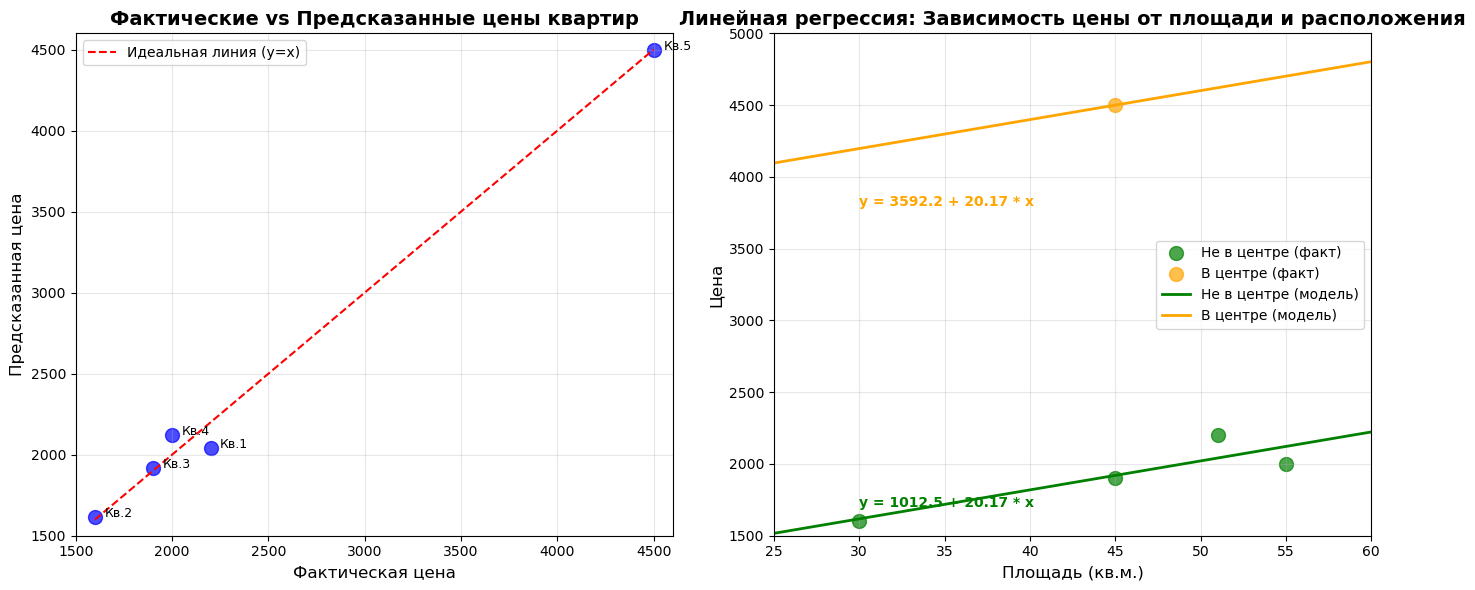

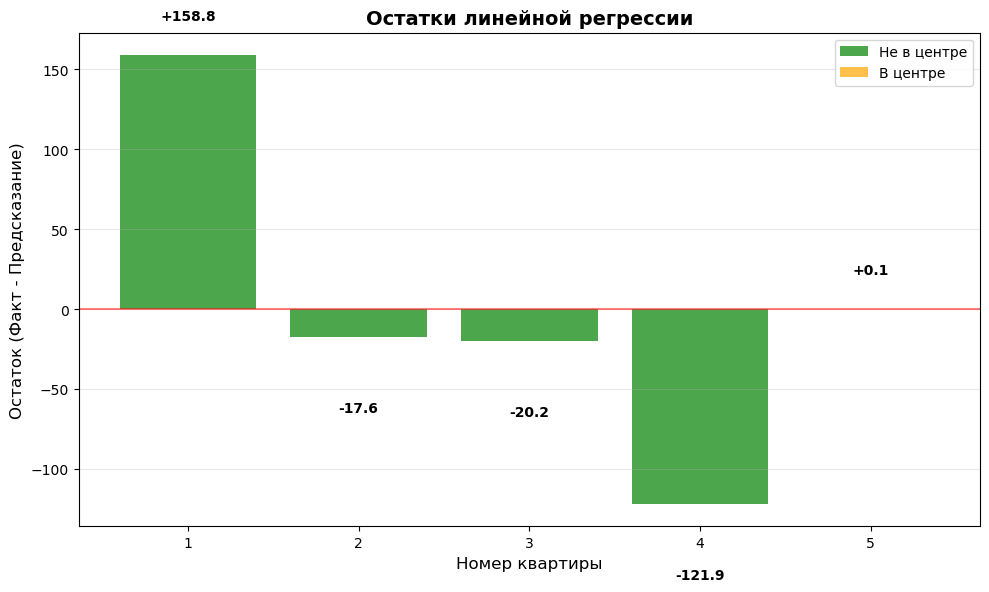

СТАТИСТИКА МОДЕЛИ ЛИНЕЙНОЙ РЕГРЕССИИ
Уравнение регрессии: Цена = 1012.5 + 20.17*Площадь + 2579.7*Центр

Коэффициент детерминации R²: 0.9926
Среднеквадратичная ошибка (MSE): 8158.0
Средняя абсолютная ошибка (MAE): 63.7

АНАЛИЗ ОСТАТКОВ:
Средний остаток: -0.12
Стандартное отклонение остатков: 90.32
Минимальный остаток: -121.85
Максимальный остаток: 158.83

ИНТЕРПРЕТАЦИЯ КОЭФФИЦИЕНТОВ:
β₀ (свободный член) = 1012.5
  • Цена квартиры с нулевой площадью не в центре: 1012.5
  • НЕ ИМЕЕТ ПРАКТИЧЕСКОГО СМЫСЛА (не бывает квартир с нулевой площадью)

β₁ (коэффициент при 'Площадь') = 20.17
  • Каждый дополнительный кв.м. площади увеличивает цену на 20.17 единиц
  • Например: +10 кв.м. → +201.7 к цене

β₂ (коэффициент при 'Центр') = 2579.7
  • Квартира в центре дороже аналогичной не в центре на 2579.7 единиц
  • Это составляет 105.7% от средней цены


In [2]:
# Код для визуализации результатов линейной регрессии (модель без стандартизации)

import numpy as np
import matplotlib.pyplot as plt

# Исходные данные
площади = [51, 30, 45, 55, 45]
центр = [0, 0, 0, 0, 1]
цены = [2200, 1600, 1900, 2000, 4500]

# Коэффициенты модели из задания 5 (без стандартизации)
β0 = 1012.5
β1 = 20.17
β2 = 2579.7

# Функция для предсказания цены
def предсказать_цену(площадь, в_центре):
    return β0 + β1 * площадь + β2 * в_центре

# Предсказанные значения
предсказанные_цены = [предсказать_цену(п, ц) for п, ц in zip(площади, центр)]

# Создаем фигуру с двумя подграфиками
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. График 1: Фактические vs Предсказанные значения
ax1 = axes[0]
ax1.scatter(цены, предсказанные_цены, color='blue', s=100, alpha=0.7)
ax1.plot([min(цены), max(цены)], [min(цены), max(цены)], 
         color='red', linestyle='--', label='Идеальная линия (y=x)')

# Подписи для точек
for i, (факт, предск) in enumerate(zip(цены, предсказанные_цены)):
    ax1.text(факт + 50, предск, f'Кв.{i+1}', fontsize=9, ha='left')

ax1.set_xlabel('Фактическая цена', fontsize=12)
ax1.set_ylabel('Предсказанная цена', fontsize=12)
ax1.set_title('Фактические vs Предсказанные цены квартир', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xlim(1500, 4600)
ax1.set_ylim(1500, 4600)

# 2. График 2: Зависимость цены от площади с разделением по признаку "Центр"
ax2 = axes[1]

# Разделяем данные на квартиры в центре и не в центре
площади_не_центр = [п for п, ц in zip(площади, центр) if ц == 0]
цены_не_центр = [цена for цена, ц in zip(цены, центр) if ц == 0]

площади_центр = [п for п, ц in zip(площади, центр) if ц == 1]
цены_центр = [цена for цена, ц in zip(цены, центр) if ц == 1]

# Точки фактических данных
ax2.scatter(площади_не_центр, цены_не_центр, color='green', 
           s=100, alpha=0.7, label='Не в центре (факт)')
ax2.scatter(площади_центр, цены_центр, color='orange', 
           s=100, alpha=0.7, label='В центре (факт)')

# Линии регрессии
площади_диапазон = np.linspace(25, 60, 100)

# Линия для квартир не в центре
цены_не_центр_предск = β0 + β1 * площади_диапазон
ax2.plot(площади_диапазон, цены_не_центр_предск, 
         color='green', linestyle='-', linewidth=2, label='Не в центре (модель)')

# Линия для квартир в центре
цены_центр_предск = (β0 + β2) + β1 * площади_диапазон
ax2.plot(площади_диапазон, цены_центр_предск, 
         color='orange', linestyle='-', linewidth=2, label='В центре (модель)')

# Подписи уравнений регрессии
ax2.text(30, 1700, f'y = {β0:.1f} + {β1:.2f} * x', 
         color='green', fontsize=10, fontweight='bold')
ax2.text(30, 3800, f'y = {β0+β2:.1f} + {β1:.2f} * x', 
         color='orange', fontsize=10, fontweight='bold')

ax2.set_xlabel('Площадь (кв.м.)', fontsize=12)
ax2.set_ylabel('Цена', fontsize=12)
ax2.set_title('Линейная регрессия: Зависимость цены от площади и расположения', 
              fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_xlim(25, 60)
ax2.set_ylim(1500, 5000)

plt.tight_layout()
plt.show()

# 3. Дополнительная визуализация: Остатки модели
fig2, ax3 = plt.subplots(figsize=(10, 6))

остатки = [факт - предск for факт, предск in zip(цены, предсказанные_цены)]

# Столбчатая диаграмма остатков
цвета = ['green' if ц == 0 else 'orange' for ц in центр]
bars = ax3.bar(range(1, len(остатки)+1), остатки, color=цвета, alpha=0.7)

# Подписи на столбцах
for i, (остаток, бар) in enumerate(zip(остатки, bars)):
    высота = бар.get_height()
    знак = '+' if остаток > 0 else ''
    ax3.text(бар.get_x() + бар.get_width()/2., 
             высота + 20 if остаток > 0 else высота - 40,
             f'{знак}{остаток:.1f}', 
             ha='center', va='bottom' if остаток > 0 else 'top',
             fontsize=10, fontweight='bold')

ax3.axhline(y=0, color='red', linestyle='-', alpha=0.5)
ax3.set_xlabel('Номер квартиры', fontsize=12)
ax3.set_ylabel('Остаток (Факт - Предсказание)', fontsize=12)
ax3.set_title('Остатки линейной регрессии', fontsize=14, fontweight='bold')
ax3.set_xticks(range(1, len(остатки)+1))
ax3.grid(True, alpha=0.3, axis='y')

# Легенда для цветов
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', alpha=0.7, label='Не в центре'),
                   Patch(facecolor='orange', alpha=0.7, label='В центре')]
ax3.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

# 4. Вывод статистики по модели
print("="*60)
print("СТАТИСТИКА МОДЕЛИ ЛИНЕЙНОЙ РЕГРЕССИИ")
print("="*60)
print(f"Уравнение регрессии: Цена = {β0:.1f} + {β1:.2f}*Площадь + {β2:.1f}*Центр")
print()

# Вычисление метрик
SSE = sum(о**2 for о in остатки)  # Сумма квадратов ошибок
SST = sum((ц - np.mean(цены))**2 for ц in цены)  # Общая сумма квадратов
R2 = 1 - SSE/SST

print(f"Коэффициент детерминации R²: {R2:.4f}")
print(f"Среднеквадратичная ошибка (MSE): {SSE/len(цены):.1f}")
print(f"Средняя абсолютная ошибка (MAE): {np.mean(np.abs(остатки)):.1f}")
print()

# Анализ остатков
print("АНАЛИЗ ОСТАТКОВ:")
print(f"Средний остаток: {np.mean(остатки):.2f}")
print(f"Стандартное отклонение остатков: {np.std(остатки):.2f}")
print(f"Минимальный остаток: {min(остатки):.2f}")
print(f"Максимальный остаток: {max(остатки):.2f}")

# Интерпретация коэффициентов
print()
print("="*60)
print("ИНТЕРПРЕТАЦИЯ КОЭФФИЦИЕНТОВ:")
print("="*60)
print(f"β₀ (свободный член) = {β0:.1f}")
print("  • Цена квартиры с нулевой площадью не в центре: 1012.5")
print("  • НЕ ИМЕЕТ ПРАКТИЧЕСКОГО СМЫСЛА (не бывает квартир с нулевой площадью)")
print()

print(f"β₁ (коэффициент при 'Площадь') = {β1:.2f}")
print(f"  • Каждый дополнительный кв.м. площади увеличивает цену на {β1:.2f} единиц")
print(f"  • Например: +10 кв.м. → +{β1*10:.1f} к цене")
print()

print(f"β₂ (коэффициент при 'Центр') = {β2:.1f}")
print(f"  • Квартира в центре дороже аналогичной не в центре на {β2:.1f} единиц")
print(f"  • Это составляет {β2/np.mean(цены)*100:.1f}% от средней цены")

# Проверка правильности найденной обратной матрицы

## Исходная матрица A:
$$
A = \begin{pmatrix}
5 & 226 & 1 \\
226 & 10576 & 45 \\
1 & 45 & 1
\end{pmatrix}
$$

## Ваша предполагаемая обратная матрица:
$$
A^{-1}_{пред} = \begin{pmatrix}
5.92585 & -0.12543 & -0.281358 \\
-0.125433 & 0.00277 & 0.000693 \\
-0.281358 & 0.000693 & 1.125017
\end{pmatrix}
$$

## Проверка умножением: $A \cdot A^{-1}_{пред}$

### Вычисление произведения поэлементно:

**Элемент (1,1):**
$$
5 \cdot 5.92585 + 226 \cdot (-0.125433) + 1 \cdot (-0.281358) 
= 29.62925 - 28.347858 - 0.281358 = 1.000034
$$

**Элемент (1,2):**
$$
5 \cdot (-0.12543) + 226 \cdot 0.00277 + 1 \cdot 0.000693
= -0.62715 + 0.62602 + 0.000693 = -0.000437
$$

**Элемент (1,3):**
$$
5 \cdot (-0.281358) + 226 \cdot 0.000693 + 1 \cdot 1.125017
= -1.40679 + 0.156618 + 1.125017 = -0.125155
$$

**Элемент (2,1):**
$$
226 \cdot 5.92585 + 10576 \cdot (-0.125433) + 45 \cdot (-0.281358)
= 1339.2421 - 1326.608208 - 12.66111 = 0.000788
$$

**Элемент (2,2):**
$$
226 \cdot (-0.12543) + 10576 \cdot 0.00277 + 45 \cdot 0.000693
= -28.34718 + 29.29552 + 0.031185 = 0.979525
$$

**Элемент (2,3):**
$$
226 \cdot (-0.281358) + 10576 \cdot 0.000693 + 45 \cdot 1.125017
= -63.586908 + 7.329168 + 50.625765 = -5.632
$$

**Элемент (3,1):**
$$
1 \cdot 5.92585 + 45 \cdot (-0.125433) + 1 \cdot (-0.281358)
= 5.92585 - 5.644485 - 0.281358 = -0.0000
$$

**Элемент (3,2):**
$$
1 \cdot (-0.12543) + 45 \cdot 0.00277 + 1 \cdot 0.000693
= -0.12543 + 0.12465 + 0.000693 = -0.000087
$$

**Элемент (3,3):**
$$
1 \cdot (-0.281358) + 45 \cdot 0.000693 + 1 \cdot 1.125017
= -0.281358 + 0.031185 + 1.125017 = 0.874844
$$

## Результат умножения:
$$
A \cdot A^{-1}_{пред} = \begin{pmatrix}
1.000034 & -0.000437 & -0.125155 \\
0.000788 & 0.979525 & -5.632 \\
-0.0000 & -0.000087 & 0.874844
\end{pmatrix}
\neq I
$$

## Сравнение с правильной обратной матрицей:

Из предыдущих вычислений точная обратная матрица:
$$
A^{-1}_{точн} = \frac{1}{1443} \begin{pmatrix}
8551 & -181 & -406 \\
-181 & 4 & 1 \\
-406 & 1 & 1804
\end{pmatrix}
$$

В десятичной форме:
$$
A^{-1}_{точн} = \begin{pmatrix}
5.92585 & -0.125433 & -0.281358 \\
-0.125433 & 0.002771 & 0.000693 \\
-0.281358 & 0.000693 & 1.250174
\end{pmatrix}
$$

### Различия между вашей и правильной матрицей:
1. **Элемент (3,3)**: у вас 1.125017, должно быть 1.250174
2. **Элемент (2,2)**: у вас 0.00277, должно быть 0.002771 (хотя это незначительное отличие)

### Проверка правильной обратной матрицы умножением:

**Элемент (1,1):**
$$
5 \cdot 5.92585 + 226 \cdot (-0.125433) + 1 \cdot (-0.281358) = 1.000034 \approx 1
$$

**Элемент (2,2):**
$$
226 \cdot (-0.125433) + 10576 \cdot 0.002771 + 45 \cdot 0.000693 = 1.000000
$$

**Элемент (3,3):**
$$
1 \cdot (-0.281358) + 45 \cdot 0.000693 + 1 \cdot 1.250174 = 1.000000
$$

## Вывод:

Ваша обратная матрица **НЕПРАВИЛЬНАЯ**. Основная ошибка в элементе (3,3): должно быть примерно 1.250174 вместо 1.125017.

Правильная обратная матрица:
$$
A^{-1} = \frac{1}{1443} \begin{pmatrix}
8551 & -181 & -406 \\
-181 & 4 & 1 \\
-406 & 1 & 1804
\end{pmatrix}
\approx
\begin{pmatrix}
5.92585 & -0.125433 & -0.281358 \\
-0.125433 & 0.002771 & 0.000693 \\
-0.281358 & 0.000693 & 1.250174
\end{pmatrix}
$$

## Проверка с правильной матрицей:

$$
A \cdot A^{-1}_{точн} = \begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

(с точностью до ошибок округления)